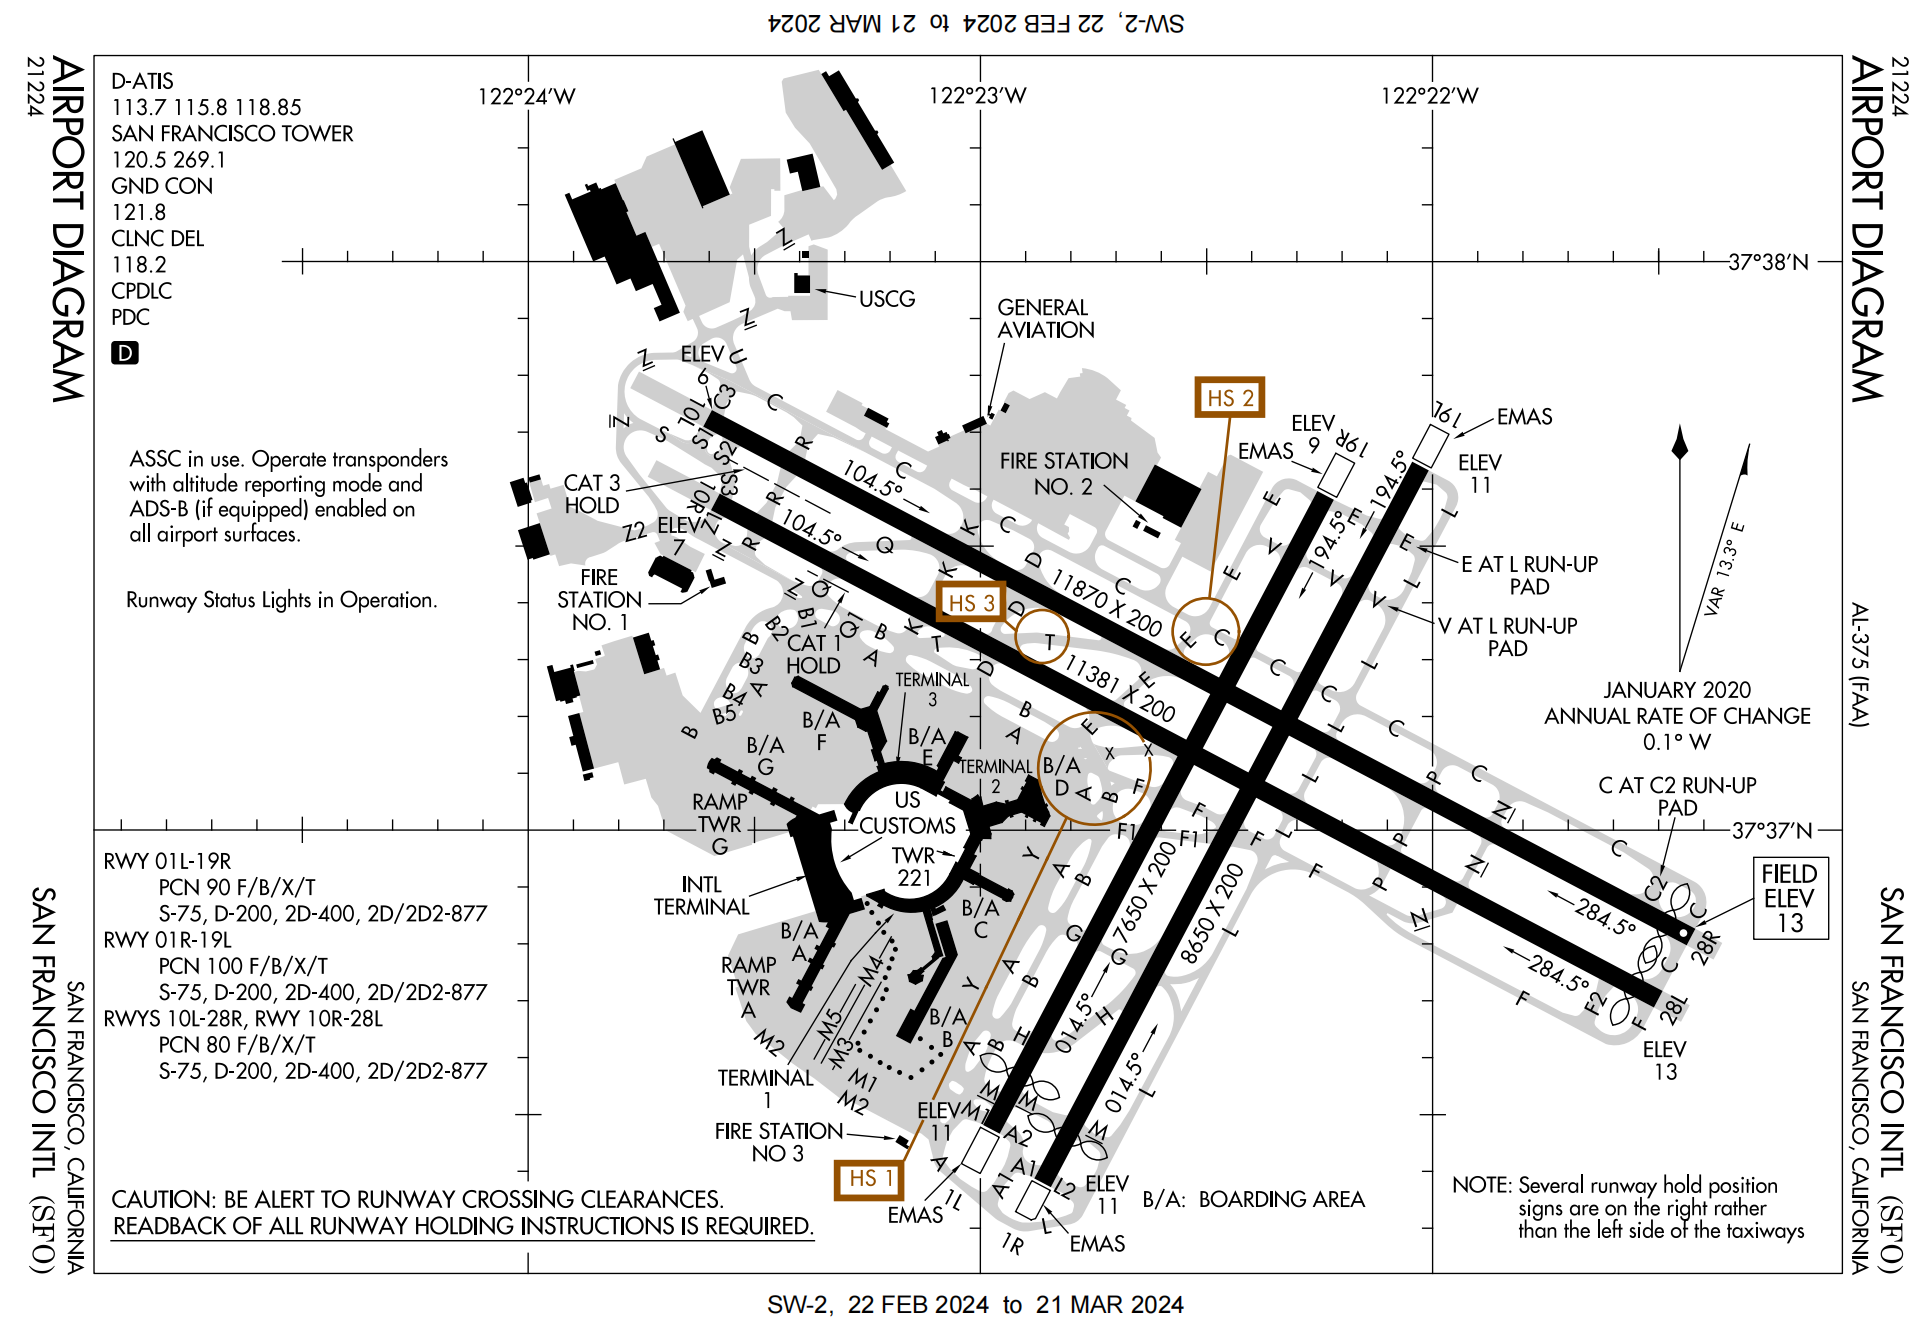

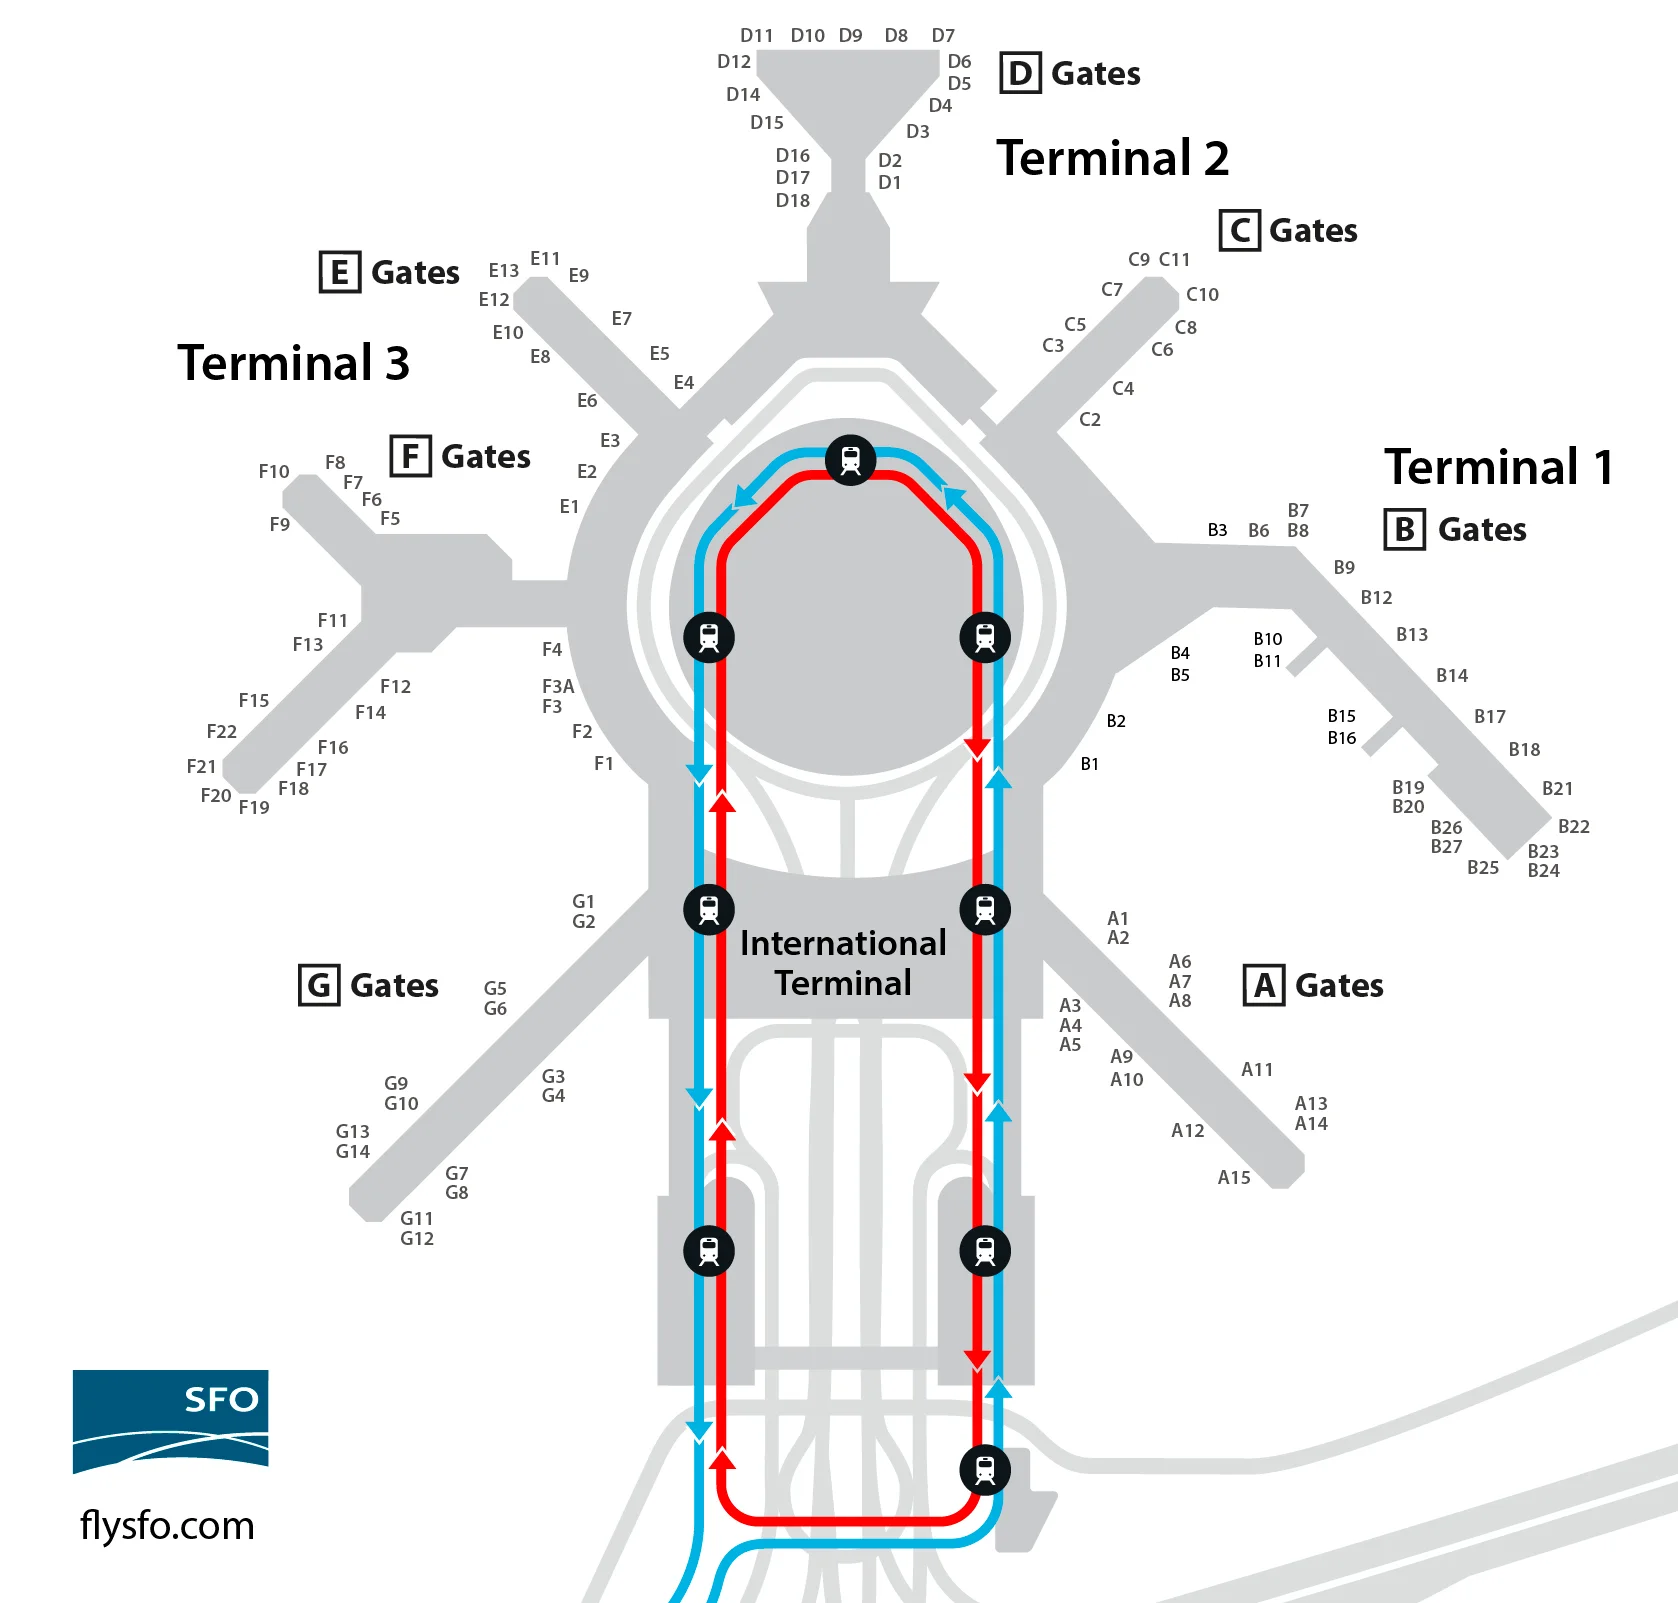

SFO Airline Preferences: 1. All Oneworld alliance airlines use Terminal 1 or the adjacent International Terminal A boarding area. Gate C, which was relocated to Terminal 2 due to reconstruction, has officially returned to Terminal 1, and Delta Air Lines' check-in counters have therefore moved to Terminal 1. 2. Terminal 2 is shared by Air Canada and Breeze Airlines. 3. Terminal 3 is a major hub for United Airlines' domestic flights. 4. Most Star Alliance airlines use International Terminal G boarding area, while Oneworld and SkyTeam airlines use International Terminal A boarding area.

---wikipedia


# SFO Gate & Remote Stand Simulation

## Modelling Assumptions

## 1. Terminal & Concourse Layout

| Terminal | Concourse | Gate Prefix       | Function        |
|----------|-----------|-------------------|-----------------|
| T1       | B, C      | B1–B27, C1–C11     | Domestic only   |
| T2       | D         | D1–D18            | Domestic only   |
| T3       | E, F      | E1–E13, F1–F22     | Domestic only   |
| INTL     | A, G      | A1–A15, G1–G14     | International   |


## 2. Airline–Terminal Allocation Assumptions

| Airline Group / Carrier Type | Primary Terminal / Area |
|------------------------------|--------------------------|
| oneworld alliance            | T1 and INTL A            |
| SkyTeam alliance             | INTL A                   |
| Star Alliance (international)| INTL G                   |
| United Airlines (domestic hub)| T3 (E/F)                |
| Air Canada, Breeze Airways   | T2 (D)                   |

Additional assumptions:
- Delta Air Lines check-in and domestic operations are consolidated into Terminal 1.


## 3. Gate Typology Overview

| Gate Type               | Quantity | Description |
|------------------------|----------|-------------|
| Contact Gates          | 120      | Jet-bridge stands across all concourses |
| Remote Boarding Gates  | 4        | Passenger-facing bus-boarding gates |
| Physical Remote Stands | 6        | Aircraft hardstands without jet bridges |


## 4. Remote Boarding Gate Structure

Remote boarding gates serve passengers only. Aircraft are parked on physical remote stands.

### Remote Boarding Gate Allocation

| Gate ID | Location | Flight Type | Supported Aircraft |
|--------|----------|-------------|--------------------|
| R-G01  | INTL G   | International | Widebody (Code D/E) |
| R-G02  | INTL G   | International | Widebody (Code D/E) |
| R-A01  | INTL A   | International | Narrow / Medium |
| R-B01  | T1 (B)   | Domestic     | Narrow / Medium |

Total remote boarding gates: 4  
International : Domestic = 3 : 1

## 5. Physical Remote Stand Pool

| Stand Group | Quantity | Aircraft Compatibility |
|-------------|----------|------------------------|
| HS-WB       | 3        | Widebody-capable (Code D/E and below) |
| HS-NB       | 3        | Narrow / Medium only (Code C) |

Stand allocation rules:
- HS-WB can accommodate widebody aircraft and all smaller aircraft categories.
- HS-NB can accommodate narrow or medium aircraft only.
- HS-WB are exclusively assigned to R-G01 and R-G02.
- HS-NB are shared between R-A01 and R-B01.
- Each physical remote stand can accommodate only one aircraft at any given time.

## 6. Aircraft Type Assumptions

| Flight Type | Aircraft Category | Notes |
|-------------|-------------------|------|
| Domestic    | Code C            | Narrowbody |
| International (G) | Code D/E    | Widebody required |
| International (A) | Code C/D    | Narrow or medium widebody |

International widebody carriers include:
AF, BA, CX, MU, QF, JL, CI, AC


## 7. Contact Gate Aircraft Compatibility Assumptions

Widebody-capable contact gates can accommodate widebody aircraft and all smaller aircraft categories.  
Narrowbody gates are restricted to narrow or medium aircraft only.

| Concourse | Narrow / Medium | Widebody-capable | Total |
|-----------|-----------------|------------------|-------|
| A         | 6               | 9                | 15    |
| B         | 20              | 7                | 27    |
| C         | 8               | 3                | 11    |
| D         | 12              | 6                | 18    |
| E         | 9               | 4                | 13    |
| F         | 11              | 11               | 22    |
| G         | 0               | 14               | 14    |

Widebody aircraft must be assigned to widebody-capable gates.  
Narrowbody aircraft are preferentially assigned to narrowbody gates, but may use widebody-capable gates if necessary.

## 8. Aircraft Turnaround Time Assumptions

Turnaround time is differentiated by aircraft category.

| Aircraft Category | Minimum Turnaround Time |
|-------------------|-------------------------|
| Narrowbody (Code C) | 45–60 minutes |
| Widebody (Code D/E) | 75–120 minutes |

Turnaround time includes standard ground handling operations but excludes additional buffer constraints defined below.

## 9. Stand-Level Constraints (Aircraft Stands)

Stand assignment is performed prior to gate assignment.

### Stand Preference (soft)
- Contact stands are always preferred.
- Remote stands are used only when no compatible contact stand is available.

### Stand Compatibility and Hierarchy (soft/hard)
- Widebody-capable stands can accommodate widebody and all smaller aircraft categories.
- Narrowbody stands can accommodate narrow or medium aircraft only.
- Widebody aircraft must always be assigned to widebody-capable stands.
- Narrowbody aircraft are preferentially assigned to narrowbody stands, but may be assigned to widebody-capable stands if narrowbody capacity is exhausted.

### Temporal Constraints (hard)
- Same-Stand Minimum Buffer (SGMB):  
  Two consecutive aircraft occupying the same stand must be separated by at least SGMB minutes beyond turnaround time.
- Adjacent Gate Safety Interval (AGSI):  
  Aircraft at adjacent stands must have at least AGSI minutes separation during docking and pushback operations.

### Uniqueness (hard)
- Each physical stand can accommodate only one aircraft at any given time.
- Stand occupancy must be temporally exclusive.

## 10. Gate-Level Constraints (Passenger Boarding Gates)

Gate assignment is performed after a feasible stand has been allocated.

### Intl/Domestic constraint (hard)
- International flights must use international terminals or international remote boarding gates.
- Domestic flights must use domestic terminals or domestic remote boarding gates.
- International and domestic classification cannot be relaxed.

### Terminal Legality (soft)
- Each airline is restricted to operate within its approved terminal set.

### Airline Preference (soft)
- Within legal terminals, airlines may prefer specific concourses or gate areas.
- Airline preference violations are permitted only if no feasible solution exists under hard constraints.

### Gate Temporal Constraints (hard)
- Same-Gate Minimum Buffer (SGMB):  
  Two consecutive aircraft using the same boarding gate must be separated by at least SGMB minutes beyond turnaround time.

### International Flight Gate Allocation Priority Rules (soft)

- United Airlines: International flights are prioritized for INTL G
- Frontier Airlines: International flights are prioritized for INTL A
- All other international flights: Priority is given to INTL A
- INTL G will only be assigned if no compatible gates are available at INTL A.

### Uniqueness (hard)
- Each flight must be assigned exactly one boarding gate or one remote boarding gate.
- Multiple or partial gate assignments are not permitted.

## 11. Constraint Relaxation Policy

Constraint relaxation follows a hierarchical order:

1. Non-widebody aircraft can be on the widebody stand.
2. Airline gate-area preference may be relaxed.
3. Terminal legality may be relaxed only if no feasible solution exists.
4. International / domestic classification must never be relaxed.

## 12. Remote Gate–Stand Mapping Model

| Remote Gate | Allowed Stands |
|-------------|----------------|
| R-G01 | HS-WB (3) |
| R-G02 | HS-WB (3) |
| R-A01 | HS-NB (3) |
| R-B01 | HS-NB (3) |

## 13. Simulated Daily Flight Schedule Overview

A synthetic daily departure schedule is generated to approximate SFO-scale operations (560 departures per day).


| Airline | IATA | Terminal | Departures (total) | Domestic | International | Non-Widebody | Widebody |
|--------|------|----------|--------------------|----------|---------------|--------------|----------|
| United Airlines | UA | T3 (pref.) / T2 / INTL G | 295 | 251 | 44 | 251 | 44 |
| Alaska Airlines | AS | T1 | 66 | 66 | 0 | 66 | 0 |
| Delta Air Lines | DL | T1 (C pref.) | 43 | 43 | 0 | 43 | 0 |
| American Airlines | AA | T1 (B pref.) | 41 | 41 | 0 | 41 | 0 |
| Southwest Airlines | WN | T2 (pref.) | 24 | 24 | 0 | 24 | 0 |
| JetBlue Airways | B6 | T1 | 13 | 13 | 0 | 13 | 0 |
| Frontier Airlines | F9 | INTL A | 12 | 0 | 12 | 12 | 0 |
| Air Canada | AC | T2 | 10 | 10 | 0 | 10 | 0 |
| Aeromexico | AM | INTL A | 3 | 0 | 3 | 3 | 0 |
| Cathay Pacific | CX | INTL G | 3 | 0 | 3 | 0 | 3 |
| EVA Air | BR | INTL G | 3 | 0 | 3 | 0 | 3 |
| Hawaiian Airlines | HA | T1 | 3 | 3 | 0 | 3 | 0 |
| Virgin Atlantic | VS | INTL A | 2 | 0 | 2 | 0 | 2 |
| British Airways | BA | INTL A | 2 | 0 | 2 | 0 | 2 |
| Air France | AF | INTL A | 2 | 0 | 2 | 0 | 2 |
| Japan Airlines | JL | INTL G | 2 | 0 | 2 | 0 | 2 |
| Lufthansa | LH | INTL G | 2 | 0 | 2 | 0 | 2 |
| Singapore Airlines | SQ | INTL G | 2 | 0 | 2 | 0 | 2 |
| Sun Country | SY | T1 | 2 | 2 | 0 | 2 | 0 |
| WestJet | WS | T2 | 2 | 2 | 0 | 2 | 0 |
| Aer Lingus | EI | INTL A | 1 | 0 | 1 | 1 | 0 |
| Air India | AI | INTL A | 1 | 0 | 1 | 0 | 1 |
| ANA | NH | INTL G | 2 | 0 | 2 | 0 | 2 |
| Asiana Airlines | OZ | INTL G | 1 | 0 | 1 | 0 | 1 |
| Avianca | AV | INTL A | 2 | 0 | 2 | 2 | 0 |
| China Airlines | CI | INTL G | 1 | 0 | 1 | 0 | 1 |
| China Eastern | MU | INTL G | 1 | 0 | 1 | 0 | 1 |
| Condor | DE | INTL A | 1 | 0 | 1 | 0 | 1 |
| Copa Airlines | CM | INTL A | 1 | 0 | 1 | 1 | 0 |
| Emirates | EK | INTL A | 1 | 0 | 1 | 0 | 1 |
| Fiji Airways | FJ | INTL G | 1 | 0 | 1 | 0 | 1 |
| Flair Airlines | F8 | INTL A | 1 | 0 | 1 | 1 | 0 |
| French Bee | BF | INTL A | 2 | 0 | 2 | 0 | 2 |
| Iberia | IB | INTL A | 1 | 0 | 1 | 1 | 0 |
| KLM | KL | INTL A | 1 | 0 | 1 | 0 | 1 |
| Korean Air | KE | INTL G | 1 | 0 | 1 | 0 | 1 |
| Philippine Airlines | PR | INTL G | 1 | 0 | 1 | 0 | 1 |
| Qantas | QF | INTL G | 1 | 0 | 1 | 0 | 1 |
| Qatar Airways | QR | INTL A | 1 | 0 | 1 | 0 | 1 |
| SAS | SK | INTL G | 1 | 0 | 1 | 0 | 1 |
| SWISS | LX | INTL G | 1 | 0 | 1 | 0 | 1 |
| TAP Air Portugal | TP | INTL A | 1 | 0 | 1 | 1 | 0 |
| Turkish Airlines | TK | INTL A | 1 | 0 | 1 | 0 | 1 |
| Vietnam Airlines | VN | INTL G | 1 | 0 | 1 | 0 | 1 |
| ZIPAIR | ZG | INTL G | 1 | 0 | 1 | 0 | 1 |
| **TOTAL** |  |  | **560** | **455** | **105** | **477** | **83** |


In [ ]:
# This chunk is to simulate the flight data.
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

# =========================================================
# 0) Reproducibility
# =========================================================
np.random.seed(42)
random.seed(42)

# =========================================================
# 1) Time Settings
# =========================================================
BASE_DATE = datetime(2025, 8, 21)
DAY_START = BASE_DATE.replace(hour=5, minute=0)
DAY_END   = BASE_DATE.replace(hour=23, minute=55)

# =========================================================
# 2) Delay Model (time-of-day dependent)
# =========================================================
DELAY_WINDOW_HIGH = (15, 17)
P_DELAY_HIGH = 0.70
P_DELAY_LOW  = 0.20
SEVERE_FRAC  = 0.20
SEVERE_RANGE = (60, 180)
MILD_RANGE   = (10, 45)

def sample_inbound_delay(dep_time: datetime) -> int:
    h = dep_time.hour
    p = P_DELAY_HIGH if DELAY_WINDOW_HIGH[0] <= h < DELAY_WINDOW_HIGH[1] else P_DELAY_LOW
    if random.random() > p:
        return 0
    return (
        random.randint(*SEVERE_RANGE)
        if random.random() < SEVERE_FRAC
        else random.randint(*MILD_RANGE)
    )

# =========================================================
# 3) Airline Daily Plan (560 flights)
# (airline, domestic, international, intl_is_widebody)
# =========================================================
AIRLINE_PLAN = [
    ("UA", 251, 44, True),
    ("AS", 66, 0, False),
    ("DL", 43, 0, False),
    ("AA", 41, 0, False),
    ("WN", 24, 0, False),
    ("B6", 13, 0, False),
    ("F9", 0, 12, False),
    ("AC", 10, 0, False),
    ("AM", 0, 3, False),
    ("CX", 0, 3, True),
    ("BR", 0, 3, True),
    ("HA", 3, 0, False),
    ("VS", 0, 2, True),
    ("BA", 0, 2, True),
    ("AF", 0, 2, True),
    ("JL", 0, 2, True),
    ("LH", 0, 2, True),
    ("SQ", 0, 2, True),
    ("SY", 2, 0, False),
    ("WS", 2, 0, False),
    ("EI", 0, 1, False),
    ("AI", 0, 1, True),
    ("NH", 0, 2, True),
    ("OZ", 0, 1, True),
    ("AV", 0, 2, False),
    ("CI", 0, 1, True),
    ("MU", 0, 1, True),
    ("DE", 0, 1, True),
    ("CM", 0, 1, False),
    ("EK", 0, 1, True),
    ("FJ", 0, 1, True),
    ("F8", 0, 1, False),
    ("BF", 0, 2, True),
    ("IB", 0, 1, False),
    ("KL", 0, 1, True),
    ("KE", 0, 1, True),
    ("PR", 0, 1, True),
    ("QF", 0, 1, True),
    ("QR", 0, 1, True),
    ("SK", 0, 1, True),
    ("LX", 0, 1, True),
    ("TP", 0, 1, False),
    ("TK", 0, 1, True),
    ("VN", 0, 1, True),
    ("ZG", 0, 1, True),
]

TOTAL_FLIGHTS = sum(dom + intl for _, dom, intl, _ in AIRLINE_PLAN)
assert TOTAL_FLIGHTS == 560, f"Total flights = {TOTAL_FLIGHTS}, expected 560"

# =========================================================
# 4) Build flight demand pool (NO TIME YET)
# =========================================================
flight_pool = []

for airline, dom, intl, intl_wb in AIRLINE_PLAN:
    # Domestic flights
    for _ in range(dom):
        flight_pool.append({
            "Airline": airline,
            "Is_International": False,
            "Is_Widebody": False
        })
    # International flights
    for _ in range(intl):
        flight_pool.append({
            "Airline": airline,
            "Is_International": True,
            "Is_Widebody": intl_wb
        })

# Randomize order so airlines are mixed across the day
random.shuffle(flight_pool)

# =========================================================
# 5) Sample departure times (with mild peak structure)
# =========================================================
def sample_departure_time():
    """
    Sample a departure time with higher density in morning/evening peaks.
    """
    peaks = [(6, 9), (16, 19)]
    weights = []

    current = DAY_START
    times = []

    while current <= DAY_END:
        h = current.hour
        w = 1.5 if any(a <= h < b for a, b in peaks) else 1.0
        times.append(current)
        weights.append(w)
        current += timedelta(minutes=5)

    t = random.choices(times, weights=weights, k=1)[0]
    return t + timedelta(minutes=random.randint(0, 4))

# =========================================================
# 6) Generate final synthetic schedule
# =========================================================
rows = []

used_flight_numbers = set()

def generate_flight_id(airline):
    while True:
        num = random.randint(100, 9999)
        fid = f"{airline}{num}"
        if fid not in used_flight_numbers:
            used_flight_numbers.add(fid)
            return fid

for flight in flight_pool:
    dep_time = sample_departure_time()

    turn = (
        random.randint(75, 120)
        if flight["Is_Widebody"]
        else random.randint(45, 60)
    )

    sched_arr = dep_time - timedelta(minutes=turn)
    delay = sample_inbound_delay(dep_time)
    actual_arr = sched_arr + timedelta(minutes=delay)

    rows.append({
        "Flight_ID": generate_flight_id(flight["Airline"]),
        "Airline": flight["Airline"],
        "Is_International": flight["Is_International"],
        "Is_Widebody": flight["Is_Widebody"],
        "Scheduled_ARR_prevleg": sched_arr,
        "Inbound_Delay_MIN": delay,
        "Actual_ARR_prevleg": actual_arr,
        "Scheduled_DEP": dep_time,
        "Assigned_Gate": None,
        "Assigned_Stand": None,
        "Is_Remote": None
    })

flights_df = pd.DataFrame(rows).sort_values("Scheduled_DEP").reset_index(drop=True)

# =========================================================
# 7) Final Validation & Export
# =========================================================
print("Synthetic SFO flight schedule generated")
print("Total flights:", len(flights_df))
print(flights_df.head(10))

flights_df.to_csv(
    "sfo_flight_schedule_simulated.csv",
    index=False,
    encoding="utf-8-sig"
)


Synthetic SFO flight schedule generated
Total flights: 560
  Flight_ID Airline  Is_International  Is_Widebody Scheduled_ARR_prevleg  \
0    AA1603      AA             False        False   2025-08-21 04:09:00   
1    DL4797      DL             False        False   2025-08-21 04:26:00   
2     UA752      UA             False        False   2025-08-21 04:35:00   
3    WN4048      WN             False        False   2025-08-21 04:33:00   
4    UA8747      UA             False        False   2025-08-21 04:37:00   
5    UA7638      UA             False        False   2025-08-21 04:37:00   
6    AA2792      AA             False        False   2025-08-21 04:39:00   
7    AS1059      AS             False        False   2025-08-21 04:42:00   
8    AA5851      AA             False        False   2025-08-21 04:43:00   
9    UA5929      UA             False        False   2025-08-21 04:38:00   

   Inbound_Delay_MIN  Actual_ARR_prevleg       Scheduled_DEP Assigned_Gate  \
0                 11 2025-

In [ ]:
# =========================================================
# SFO Pre-assignment: Joint Gate + Stand (Hierarchical Relaxation)
# =========================================================

from collections import defaultdict
from datetime import timedelta

# =========================================================
# 0) Buffers & safety
# =========================================================
SGMB_STAND_MIN = 10
SGMB_GATE_MIN  = 10
AGSI_MIN     = 5
BUFFER_AFTER_DEP = 10

# =========================================================
# 1) Gate / Stand topology
# =========================================================

A_GATES = [f"A{i:02d}" for i in range(1, 16)]
B_GATES = [f"B{i:02d}" for i in range(1, 28)]
C_GATES = [f"C{i:02d}" for i in range(1, 12)]
D_GATES = [f"D{i:02d}" for i in range(1, 19)]
E_GATES = [f"E{i:02d}" for i in range(1, 14)]
F_GATES = [f"F{i:02d}" for i in range(1, 23)]
G_GATES = [f"G{i:02d}" for i in range(1, 15)]

CONTACT_GATES  = A_GATES + B_GATES + C_GATES + D_GATES + E_GATES + F_GATES + G_GATES
CONTACT_STANDS = CONTACT_GATES.copy()

REMOTE_GATES = ["R-G01", "R-G02", "R-A01", "R-B01"]

HS_WB = [f"HS-WB{i}" for i in range(1, 4)]
HS_NB = [f"HS-NB{i}" for i in range(1, 4)]

REMOTE_GATE_STAND_MAP = {
    "R-G01": HS_WB,
    "R-G02": HS_WB,
    "R-A01": HS_NB,
    "R-B01": HS_NB,
}

# =========================================================
# 2) Capability definitions
# =========================================================

WB_CONTACT_GATES = (
    G_GATES
    + A_GATES[:9]
    + B_GATES[:7]
    + C_GATES[:3]
    + D_GATES[:6]
    + E_GATES[:4]
    + F_GATES[:11]
)

def stand_can_accept(stand_id, is_widebody, relax_capacity):
    if stand_id in HS_NB:
        return not is_widebody

    if stand_id in HS_WB:
        return is_widebody or relax_capacity

    if stand_id in CONTACT_STANDS:
        if is_widebody:
            return stand_id in WB_CONTACT_GATES
        else:
            if stand_id in WB_CONTACT_GATES:
                return relax_capacity
            return True

    return False

# =========================================================
# 3) Terminal legality
# =========================================================
AIRLINE_TERMINAL_ALLOWED = {
    "UA": {"E","F","G"},
    "AS": {"B","C"},
    "DL": {"C"},
    "AA": {"B"},
    "WN": {"D"},
    "B6": {"B","C"},
    "F9": {"A"},
    "AC": {"D"},
}

def terminal_of_gate(g):
    return g[0] if g[0] in "ABCDEFG" else g.split("-")[1][0]

# =========================================================
# 4) Adjacency
# =========================================================
def linear_adj(ids):
    adj = {}
    for i, x in enumerate(ids):
        adj[x] = set()
        if i > 0: adj[x].add(ids[i-1])
        if i < len(ids)-1: adj[x].add(ids[i+1])
    return adj

STAND_ADJ = {}
for group in [A_GATES,B_GATES,C_GATES,D_GATES,E_GATES,F_GATES,G_GATES]:
    STAND_ADJ.update(linear_adj(group))

# =========================================================
# 5) Occupancy trackers
# =========================================================
stand_usage = defaultdict(list)
gate_usage  = defaultdict(list)
stand_dock  = defaultdict(list)
stand_push = defaultdict(list)

def no_overlap(start, end, intervals, buffer_min):
    pad = timedelta(minutes=buffer_min)
    for s,e in intervals:
        if not (end + pad <= s or start >= e + pad):
            return False
    return True

def agsi_ok(stand, dock, push):
    sep = timedelta(minutes=AGSI_MIN)
    for nb in STAND_ADJ.get(stand, []):
        for t in stand_dock.get(nb, []):
            if abs(dock - t) < sep:
                return False
        for t in stand_push.get(nb, []):
            if abs(push - t) < sep:
                return False
    return True

# =========================================================
# 6) Joint assignment with hierarchical relaxation
# =========================================================
def assign_gate_and_stand(f, relax_capacity, relax_pref, relax_terminal):

    dock = f["Scheduled_ARR_prevleg"]
    push = f["Scheduled_DEP"]
    start = dock
    end   = push + timedelta(minutes=BUFFER_AFTER_DEP)

    is_wb   = f["Is_Widebody"]
    is_intl = f["Is_International"]
    airline = f["Airline"]

    gate_candidates = []

    for g in CONTACT_GATES + REMOTE_GATES:
        term = terminal_of_gate(g)

        # Intl/Dom HARD
        if is_intl and term not in {"A","G"}:
            continue
        if not is_intl and term in {"A","G"}:
            continue

        # Terminal legality
        if not relax_terminal and airline in AIRLINE_TERMINAL_ALLOWED:
            if term not in AIRLINE_TERMINAL_ALLOWED[airline]:
                continue

        gate_candidates.append(g)

    # Airline preference (soft)
    if not relax_pref and airline in AIRLINE_TERMINAL_ALLOWED:
        pref_terms = AIRLINE_TERMINAL_ALLOWED[airline]
        gate_candidates = sorted(
            gate_candidates,
            key=lambda g: terminal_of_gate(g) not in pref_terms
        )

    for g in gate_candidates:

        # -------- CONTACT --------
        if g in CONTACT_GATES:
            s = g

            if not stand_can_accept(s, is_wb, relax_capacity):
                continue
            if not no_overlap(start,end,stand_usage[s],SGMB_STAND_MIN):
                continue
            if not agsi_ok(s,dock,push):
                continue
            if not no_overlap(start,end,gate_usage[g],SGMB_GATE_MIN):
                continue

            stand_usage[s].append((start,end))
            gate_usage[g].append((start,end))
            stand_dock[s].append(dock)
            stand_push[s].append(push)

            return g, s, False

        # -------- REMOTE --------
        for s in REMOTE_GATE_STAND_MAP[g]:
            if not stand_can_accept(s, is_wb, relax_capacity):
                continue
            if not no_overlap(start,end,stand_usage[s],SGMB_STAND_MIN):
                continue
            if not agsi_ok(s,dock,push):
                continue
            if not no_overlap(start,end,gate_usage[g],SGMB_GATE_MIN):
                continue

            stand_usage[s].append((start,end))
            gate_usage[g].append((start,end))
            stand_dock[s].append(dock)
            stand_push[s].append(push)

            return g, s, True

    return None

# =========================================================
# 7) Main loop
# =========================================================
assigned_gate  = []
assigned_stand = []
is_remote_list = []

for _, f in flights_df.sort_values("Scheduled_DEP").iterrows():

    res = (
        assign_gate_and_stand(f, False, False, False) or
        assign_gate_and_stand(f, True,  False, False) or
        assign_gate_and_stand(f, True,  False, True ) or
        assign_gate_and_stand(f, True,  True,  True )
    )

    if res is None:
        raise RuntimeError(f"No feasible assignment for {f['Flight_ID']}")

    g, s, r = res
    assigned_gate.append(g)
    assigned_stand.append(s)
    is_remote_list.append(r)

flights_df["Assigned_Gate"]  = assigned_gate
flights_df["Assigned_Stand"] = assigned_stand
flights_df["Is_Remote"]    = is_remote_list

print("Pre-assignment completed successfully")
print(flights_df[["Flight_ID","Assigned_Gate","Assigned_Stand","Is_Remote"]].head(12))
flights_df.to_csv("sfo_preallocation.csv", index=False)


Pre-assignment completed successfully
   Flight_ID Assigned_Gate Assigned_Stand  Is_Remote
0     AA1603           B08            B08      False
1     DL4797           C04            C04      False
2      UA752           E05            E05      False
3     WN4048           D07            D07      False
4     UA8747           E07            E07      False
5     UA7638           E09            E09      False
6     AA2792           B09            B09      False
7     AS1059           B11            B11      False
8     AA5851           B13            B13      False
9     UA5929           E11            E11      False
10    UA9106           E06            E06      False
11    AA7538           B10            B10      False


In [ ]:
!pip install gymnasium
!pip install stable-baselines3[extra]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 4.7 MB/s eta 0:00:00


In [ ]:
def compute_effective_departure(flight):
    """
    Enforce minimum turnaround time based on aircraft type.

    Returns
    -------
    effective_dep : datetime
    """

    actual_arr = flight["Actual_ARR_prevleg"]
    sched_dep  = flight["Scheduled_DEP"]
    is_wb      = flight["Is_Widebody"]

    min_turn = 75 if is_wb else 45
    actual_turn = (sched_dep - actual_arr).total_seconds() / 60

    if actual_turn < min_turn:
        return actual_arr + timedelta(minutes=min_turn)
    else:
        return sched_dep


In [ ]:
# =========================================================
# SFO Original Assignment Feasibility (Real-time)
# =========================================================

def sfo_original_is_feasible(
    flight,
    stand_usage,
    gate_usage,
    stand_dock,
    stand_push,
):
    """
    Check whether pre-assigned (Gate, Stand) is still feasible
    under real-time delays.
    """

    g = flight["Assigned_Gate"]
    s = flight["Assigned_Stand"]

    dock = flight["Actual_ARR_prevleg"]
    push = compute_effective_departure(flight)

    start = dock
    end   = push + timedelta(minutes=BUFFER_AFTER_DEP)

    is_wb = flight["Is_Widebody"]

    # -------- Stand capability (HARD) --------
    if not stand_can_accept(s, is_wb, relax_capacity=False):
        return False, "stand_capability_violation"

    # -------- Stand SGMB --------
    if not no_overlap(start, end, stand_usage[s], SGMB_STAND_MIN):
        return False, "stand_sgmb_conflict"

    # -------- AGSI --------
    if not agsi_ok(s, dock, push):
        return False, "agsi_conflict"

    # -------- Gate SGMB --------
    if not no_overlap(start, end, gate_usage[g], SGMB_GATE_MIN):
        return False, "gate_sgmb_conflict"

    # -------- Reserve --------
    stand_usage[s].append((start, end))
    gate_usage[g].append((start, end))
    stand_dock[s].append(dock)
    stand_push[s].append(push)

    return True, None

# =========================================================
# SFO Reassignment Try (Hierarchical Relaxation)
# =========================================================

def sfo_try_reassign(
    flight,
    stand_usage,
    gate_usage,
    stand_dock,
    stand_push,
    relax_capacity=False,
    relax_pref=False,
    relax_terminal=False,
):
    dock = flight["Actual_ARR_prevleg"]
    push = compute_effective_departure(flight)

    start = dock
    end   = push + timedelta(minutes=BUFFER_AFTER_DEP)

    is_wb   = flight["Is_Widebody"]
    is_intl = flight["Is_International"]
    airline = flight["Airline"]

    # -------- Build legal gate candidates --------
    gate_candidates = []

    for g in CONTACT_GATES + REMOTE_GATES:
        term = terminal_of_gate(g)

        # Intl / Dom HARD
        if is_intl and term not in {"A", "G"}:
            continue
        if not is_intl and term in {"A", "G"}:
            continue

        # Terminal legality
        if not relax_terminal and airline in AIRLINE_TERMINAL_ALLOWED:
            if term not in AIRLINE_TERMINAL_ALLOWED[airline]:
                continue

        gate_candidates.append(g)

    # Airline preference (soft)
    if not relax_pref and airline in AIRLINE_TERMINAL_ALLOWED:
        pref_terms = AIRLINE_TERMINAL_ALLOWED[airline]
        gate_candidates = sorted(
            gate_candidates,
            key=lambda g: terminal_of_gate(g) not in pref_terms
        )

    # -------- Try assignment --------
    for g in gate_candidates:

        # ===== CONTACT =====
        if g in CONTACT_GATES:
            s = g

            if not stand_can_accept(s, is_wb, relax_capacity):
                continue
            if not no_overlap(start, end, stand_usage[s], SGMB_STAND_MIN):
                continue
            if not agsi_ok(s, dock, push):
                continue
            if not no_overlap(start, end, gate_usage[g], SGMB_GATE_MIN):
                continue

            stand_usage[s].append((start, end))
            gate_usage[g].append((start, end))
            stand_dock[s].append(dock)
            stand_push[s].append(push)

            return g, s, False

        # ===== REMOTE =====
        for s in REMOTE_GATE_STAND_MAP[g]:
            if not stand_can_accept(s, is_wb, relax_capacity):
                continue
            if not no_overlap(start, end, stand_usage[s], SGMB_STAND_MIN):
                continue
            if not agsi_ok(s, dock, push):
                continue
            if not no_overlap(start, end, gate_usage[g], SGMB_GATE_MIN):
                continue

            stand_usage[s].append((start, end))
            gate_usage[g].append((start, end))
            stand_dock[s].append(dock)
            stand_push[s].append(push)

            return g, s, True

    return None

# =========================================================
# SFO Real-time Reallocation Under Delays
# =========================================================

def sfo_reallocate_under_delays(flights_df: pd.DataFrame) -> pd.DataFrame:

    from collections import defaultdict

    stand_usage = defaultdict(list)
    gate_usage  = defaultdict(list)
    stand_dock  = defaultdict(list)
    stand_push  = defaultdict(list)

    df = flights_df.copy()

    df["Gate_Final"]   = None
    df["Stand_Final"]  = None
    df["Is_Remote_Final"] = None
    df["Realloc_Action"]  = None
    df["Realloc_Reason"]  = None

    df_proc = df.sort_values(
        ["Actual_ARR_prevleg", "Scheduled_DEP"]
    ).reset_index(drop=True)

    for i, f in df_proc.iterrows():

        # -------- Phase 0: keep original if feasible --------
        ok, reason = sfo_original_is_feasible(
            f,
            stand_usage,
            gate_usage,
            stand_dock,
            stand_push,
        )

        if ok:
            df_proc.at[i, "Gate_Final"] = f["Assigned_Gate"]
            df_proc.at[i, "Stand_Final"] = f["Assigned_Stand"]
            df_proc.at[i, "Is_Remote_Final"] = f["Is_Remote"]
            df_proc.at[i, "Realloc_Action"] = "kept_original"
            continue

        # -------- Phase 1~3: hierarchical reassignment --------
        res = (
            sfo_try_reassign(f, stand_usage, gate_usage, stand_dock, stand_push,
                             relax_capacity=False, relax_pref=False, relax_terminal=False)
            or
            sfo_try_reassign(f, stand_usage, gate_usage, stand_dock, stand_push,
                             relax_capacity=True, relax_pref=False, relax_terminal=False)
            or
            sfo_try_reassign(f, stand_usage, gate_usage, stand_dock, stand_push,
                             relax_capacity=True, relax_pref=True, relax_terminal=False)
            or
            sfo_try_reassign(f, stand_usage, gate_usage, stand_dock, stand_push,
                             relax_capacity=True, relax_pref=True, relax_terminal=True)
        )

        if res is None:
            df_proc.at[i, "Realloc_Action"] = "failed"
            df_proc.at[i, "Realloc_Reason"] = reason
            continue

        g, s, is_remote = res

        df_proc.at[i, "Gate_Final"] = g
        df_proc.at[i, "Stand_Final"] = s
        df_proc.at[i, "Is_Remote_Final"] = int(is_remote)
        df_proc.at[i, "Realloc_Action"] = "reassigned"
        df_proc.at[i, "Realloc_Reason"] = reason

    return df_proc.sort_values("Scheduled_DEP").reset_index(drop=True)


In [ ]:
# ================= Reward Weights (SFO Real-time) =================

R_ASSIGN_SUCCESS = 2.0
R_ASSIGN_FAIL    = -4.0

R_INTL_DOM_MISMATCH = -0.5
R_TERMINAL_ILLEGAL  = -0.4

R_CONTACT_GATE   = 0.6
R_REMOTE_GATE    = 0.3

R_NB_ON_NB_STAND = 0.4
R_NB_ON_WB_STAND = -0.3
R_WB_ON_WB_STAND = 0.3

R_AIRLINE_PREF   = 0.3


In [ ]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
from datetime import timedelta
from collections import defaultdict


class GateStandEnv(gym.Env):
    """
    Real-time gate & stand assignment environment with hierarchical relaxation.

    Features:
    - Fallback mechanism: tries all gates in priority order
    - Remote gate support: full logic for remote stands
    - AGSI checks: Adjacent Gate Safety Interval for all stands
    - Hierarchical relaxation: 4 levels of constraint relaxation
    - Rich diagnostic info for debugging

    Constraint Classification:
    - HARD constraints: International/Domestic segregation (enforced in action mask)
    - SOFT constraints: Airline terminal preference (handled by reward and relaxation)
    """

    metadata = {"render_modes": []}

    def __init__(self, flights_df):
        super().__init__()

        # Sort flights by actual arrival time (real-time processing order)
        self.flights = flights_df.sort_values(
            "Actual_ARR_prevleg"
        ).reset_index(drop=True)

        self.ptr = 0  # Current flight pointer

        # ---------- ACTION SPACE ----------
        self.all_gates = CONTACT_GATES + REMOTE_GATES
        self.action_space = spaces.Discrete(len(self.all_gates))

        # ---------- OBSERVATION SPACE ----------
        self.observation_space = spaces.Dict({
            "is_international": spaces.Box(0, 1, (1,), np.float32),
            "is_widebody":      spaces.Box(0, 1, (1,), np.float32),
            "delay_norm":       spaces.Box(0, 1, (1,), np.float32),
            "sched_dep_time":   spaces.Box(0, 1, (1,), np.float32),
            "actual_arr_time":  spaces.Box(0, 1, (1,), np.float32),
        })

        # ---------- STATEFUL TRACKING ----------
        # Track occupied time windows for each stand/gate
        self.stand_usage = defaultdict(list)  # [(start, end), ...]
        self.gate_usage  = defaultdict(list)  # [(start, end), ...]

        # Track specific dock/push times for AGSI checks
        self.stand_dock  = defaultdict(list)  # [dock_time, ...]
        self.stand_push  = defaultdict(list)  # [push_time, ...]

    # --------------------------------------------------
    def reset(self, *, seed=None, options=None):
        """Reset environment to initial state."""
        super().reset(seed=seed)

        self.ptr = 0
        self._original_feasible = False

        # Clear all tracking data
        self.stand_usage.clear()
        self.gate_usage.clear()
        self.stand_dock.clear()
        self.stand_push.clear()

        return self._get_state(), {}

    # --------------------------------------------------
    def _get_state(self):
        """
        Get current observation for the flight at self.ptr.
        Returns zero state if episode has ended.
        """
        if self.ptr >= len(self.flights):
            # Return zero state when episode is done
            zero = np.zeros(1, np.float32)
            return {
                "is_international": zero,
                "is_widebody": zero,
                "delay_norm": zero,
                "sched_dep_time": zero,
                "actual_arr_time": zero,
            }

        f = self.flights.loc[self.ptr]

        return {
            # Binary features (0 or 1)
            "is_international": np.array([f["Is_International"]], np.float32),
            "is_widebody":      np.array([f["Is_Widebody"]], np.float32),

            # Normalized delay (capped at 180 minutes = 3 hours)
            "delay_norm": np.array(
                [min(f["Inbound_Delay_MIN"] / 180.0, 1.0)], np.float32
            ),

            # Time of day normalized to [0, 1]
            "sched_dep_time": np.array(
                [f["Scheduled_DEP"].hour / 24.0], np.float32
            ),
            "actual_arr_time": np.array(
                [f["Actual_ARR_prevleg"].hour / 24.0], np.float32
            ),
        }

    # --------------------------------------------------
    def get_action_mask(self):
        """
        Generate action mask based on HARD constraints ONLY.

        HARD constraints (enforced here):
        - International/Domestic terminal segregation

        SOFT constraints (NOT enforced here, handled by reward):
        - Airline terminal preference
        - Stand capacity utilization
        - Airline concourse preference

        Returns:
            np.array: Binary mask (1=allowed, 0=forbidden)
        """
        if self.ptr >= len(self.flights):
            # All actions allowed when episode is done (no-op state)
            return np.ones(self.action_space.n, dtype=np.int8)

        f = self.flights.loc[self.ptr]
        is_intl = f["Is_International"]

        mask = np.ones(self.action_space.n, dtype=np.int8)

        for i, gate in enumerate(self.all_gates):
            term = terminal_of_gate(gate)

            # ---- HARD CONSTRAINT: International/Domestic segregation ----
            # International flights MUST use terminals A or G
            if is_intl and term not in {"A", "G"}:
                mask[i] = 0

            # Domestic flights CANNOT use terminals A or G
            if not is_intl and term in {"A", "G"}:
                mask[i] = 0

        return mask

    def step(self, action):
        """
        Execute one step: real-time gate assignment with KEEP-FIRST logic.

        Decision logic:
        Phase 0 (Deterministic):
            - If original assignment is still feasible → MUST KEEP
            - RL is NOT involved

        Phase 1 (RL-triggered):
            - Only when original assignment is infeasible
            - RL selects a PRIORITY gate
            - Environment performs fallback + hierarchical relaxation

        Returns:
            observation, reward, terminated, truncated, info
        """

        # --------------------------------------------------
        # Episode end check
        # --------------------------------------------------
        if self.ptr >= len(self.flights):
            return self._get_state(), 0.0, True, False, {}

        f = self.flights.loc[self.ptr]

        airline = f["Airline"]
        is_intl = f["Is_International"]
        is_wb   = f["Is_Widebody"]

        dock = f["Actual_ARR_prevleg"]
        eff_dep = compute_effective_departure(f)

        start = dock
        end   = eff_dep + timedelta(minutes=BUFFER_AFTER_DEP)

        reward = 0.0
        reward_components = defaultdict(float)

        flags = {
            "kept_original": 0,
            "assign_success": 0,
            "assign_fail": 0,
            "used_contact": 0,
            "used_remote": 0,
            "airline_pref_ok": 0,
        }

        # ==================================================
        # PHASE 0: KEEP ORIGINAL IF FEASIBLE (HARD RULE)
        # ==================================================
        ok, reason = sfo_original_is_feasible(
            f,
            self.stand_usage,
            self.gate_usage,
            self.stand_dock,
            self.stand_push,
        )
        self._original_feasible = ok

        if ok:
            # Deterministic KEEP — RL is bypassed
            reward += R_ASSIGN_SUCCESS
            reward_components["assign_success"] += R_ASSIGN_SUCCESS

            flags["kept_original"] = 1
            flags["assign_success"] = 1

            info = {
                **flags,
                "success": True,
                "assigned_gate": f["Assigned_Gate"],
                "assigned_stand": f["Assigned_Stand"],
                "is_remote": int(f.get("Is_Remote", 0)),
                "priority_gate": f["Assigned_Gate"],
                "fallback_level": 0,
                "relaxation_level": 0,
                "reward_components": dict(reward_components),
                "total_reward": reward,
                "flight_id": f["Flight_ID"],
                "airline": airline,
                "is_intl": is_intl,
                "is_wb": is_wb,
                "delay_min": f["Inbound_Delay_MIN"],
                "realloc_reason": "kept_original",
            }

            self.ptr += 1
            terminated = self.ptr >= len(self.flights)

            return self._get_state(), reward, terminated, False, info

        # ==================================================
        # PHASE 1: RL-TRIGGERED REALLOCATION
        # ==================================================

        primary_gate = self.all_gates[int(action)]
        gate_order = [primary_gate] + [g for g in self.all_gates if g != primary_gate]

        success = False
        used_gate = None
        used_stand = None
        fallback_level = None
        relaxation_level = None

        relax_levels = [
            dict(relax_capacity=False, relax_pref=False, relax_terminal=False),
            dict(relax_capacity=True,  relax_pref=False, relax_terminal=False),
            dict(relax_capacity=True,  relax_pref=True,  relax_terminal=False),
            dict(relax_capacity=True,  relax_pref=True,  relax_terminal=True),
        ]

        for lvl_idx, lvl in enumerate(relax_levels):
            for k, gate in enumerate(gate_order):

                term = terminal_of_gate(gate)

                # HARD intl/dom constraint
                if is_intl and term not in {"A", "G"}:
                    continue
                if not is_intl and term in {"A", "G"}:
                    continue

                # SOFT terminal legality
                if not lvl["relax_terminal"] and airline in AIRLINE_TERMINAL_ALLOWED:
                    if term not in AIRLINE_TERMINAL_ALLOWED[airline]:
                        continue

                # ---------- CONTACT ----------
                if gate in CONTACT_GATES:
                    s = gate

                    if (
                        stand_can_accept(s, is_wb, lvl["relax_capacity"])
                        and no_overlap(start, end, self.stand_usage[s], SGMB_STAND_MIN)
                        and agsi_ok(s, dock, eff_dep)
                        and no_overlap(start, end, self.gate_usage[gate], SGMB_GATE_MIN)
                    ):
                        success = True
                        used_gate = gate
                        used_stand = s
                        fallback_level = k
                        relaxation_level = lvl_idx

                        self.stand_usage[s].append((start, end))
                        self.gate_usage[gate].append((start, end))
                        self.stand_dock[s].append(dock)
                        self.stand_push[s].append(eff_dep)

                        reward += R_ASSIGN_SUCCESS + R_CONTACT_GATE
                        reward_components["assign_success"] += R_ASSIGN_SUCCESS
                        reward_components["contact_gate"] += R_CONTACT_GATE

                        flags["assign_success"] = 1
                        flags["used_contact"] = 1
                        break

                # ---------- REMOTE ----------
                else:
                    for s in REMOTE_GATE_STAND_MAP[gate]:
                        if (
                            stand_can_accept(s, is_wb, lvl["relax_capacity"])
                            and no_overlap(start, end, self.stand_usage[s], SGMB_STAND_MIN)
                            and agsi_ok(s, dock, eff_dep)
                            and no_overlap(start, end, self.gate_usage[gate], SGMB_GATE_MIN)
                        ):
                            success = True
                            used_gate = gate
                            used_stand = s
                            fallback_level = k
                            relaxation_level = lvl_idx

                            self.stand_usage[s].append((start, end))
                            self.gate_usage[gate].append((start, end))
                            self.stand_dock[s].append(dock)
                            self.stand_push[s].append(eff_dep)

                            reward += R_ASSIGN_SUCCESS + R_REMOTE_GATE
                            reward_components["assign_success"] += R_ASSIGN_SUCCESS
                            reward_components["remote_gate"] += R_REMOTE_GATE

                            flags["assign_success"] = 1
                            flags["used_remote"] = 1
                            break

                if success:
                    break
            if success:
                break

        if not success:
            reward += R_ASSIGN_FAIL
            reward_components["assign_fail"] += R_ASSIGN_FAIL
            flags["assign_fail"] = 1

        self.ptr += 1
        terminated = self.ptr >= len(self.flights)

        info = {
            **flags,
            "success": success,
            "assigned_gate": used_gate,
            "assigned_stand": used_stand,
            "is_remote": int(used_gate in REMOTE_GATES) if used_gate else 0,
            "priority_gate": primary_gate,
            "fallback_level": fallback_level,
            "relaxation_level": relaxation_level,
            "reward_components": dict(reward_components),
            "total_reward": reward,
            "flight_id": f["Flight_ID"],
            "airline": airline,
            "is_intl": is_intl,
            "is_wb": is_wb,
            "delay_min": f["Inbound_Delay_MIN"],
            "realloc_reason": reason,
        }

        return self._get_state(), reward, terminated, False, info

In [ ]:
import gymnasium as gym
import numpy as np


class SFOFlattenObsWrapper(gym.ObservationWrapper):
    """
    SFO-specific observation wrapper for DQN.

    Key features:
    - Flattens Dict observation into a 1D vector
    - Appends action mask
    - Appends a binary flag indicating whether RL decision is required
      (KEEP-first logic support)
    """

    def __init__(self, env):
        super().__init__(env)

        # -------- Feature dimensions --------
        feat_dim = sum(
            int(np.prod(space.shape))
            for space in env.observation_space.spaces.values()
        )

        mask_dim = env.action_space.n

        # +1 for needs_reassignment flag
        self.observation_space = gym.spaces.Box(
            low=0.0,
            high=1.0,
            shape=(feat_dim + mask_dim + 1,),
            dtype=np.float32,
        )

    def observation(self, obs):
        """
        Build flattened observation vector.

        Structure:
        [ flight_features | action_mask | needs_reassignment ]
        """

        # -------- Flight features --------
        feat = np.concatenate([
            obs["is_international"],
            obs["is_widebody"],
            obs["delay_norm"],
            obs["sched_dep_time"],
            obs["actual_arr_time"],
        ])

        # -------- Action mask --------
        mask = self.env.get_action_mask().astype(np.float32)

        # -------- Decision-required flag --------
        # 1.0 → RL decision required (original infeasible)
        # 0.0 → KEEP original, RL action ignored
        needs_reassignment = np.array(
            [0.0 if self.env._original_feasible else 1.0],
            dtype=np.float32,
        )

        return np.concatenate([feat, mask, needs_reassignment])


In [ ]:
from gymnasium.wrappers import FlattenObservation

def make_sfo_env(flights_df, flatten_obs=False):
    def _init():
        env = GateStandEnv(flights_df)
        if flatten_obs:
            env = SFOFlattenObsWrapper(env)
        return env
    return _init


In [ ]:
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

TOTAL_TIMESTEPS = 200_000

ppo_env = DummyVecEnv([
    make_sfo_env(flights_df, flatten_obs=False)
])

ppo_model = PPO(
    policy="MultiInputPolicy",
    env=ppo_env,
    learning_rate=1e-3,
    n_steps=2048,
    batch_size=128,
    gamma=0.99,
    ent_coef=0.01,
    verbose=1,
)

ppo_model.learn(total_timesteps=TOTAL_TIMESTEPS)


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Using cpu device


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------
| time/              |      |
|    fps             | 359  |
|    iterations      | 1    |
|    time_elapsed    | 5    |
|    total_timesteps | 2048 |
-----------------------------


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


-----------------------------------------
| time/                   |             |
|    fps                  | 358         |
|    iterations           | 2           |
|    time_elapsed         | 11          |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.009920365 |
|    clip_fraction        | 0.0768      |
|    clip_range           | 0.2         |
|    entropy_loss         | -4.82       |
|    explained_variance   | -0.00221    |
|    learning_rate        | 0.001       |
|    loss                 | 214         |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0259     |
|    value_loss           | 836         |
-----------------------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 350         |
|    iterations           | 3           |
|    time_elapsed         | 17          |
|    total_timesteps      | 6144  

In [ ]:
from stable_baselines3 import A2C
from stable_baselines3.common.vec_env import DummyVecEnv

a2c_env = DummyVecEnv([
    make_sfo_env(flights_df, flatten_obs=False)
])

a2c_model = A2C(
    policy="MultiInputPolicy",
    env=a2c_env,
    learning_rate=1e-3,
    n_steps=5,          # arrival-driven short rollout
    gamma=0.99,
    ent_coef=0.01,
    verbose=1,
)

a2c_model.learn(total_timesteps=TOTAL_TIMESTEPS)


流式输出内容被截断，只能显示最后 5000 行内容。
|    value_loss         | 0.159    |
------------------------------------
------------------------------------
| time/                 |          |
|    fps                | 248      |
|    iterations         | 4400     |
|    time_elapsed       | 88       |
|    total_timesteps    | 22000    |
| train/                |          |
|    entropy_loss       | -4.73    |
|    explained_variance | 3e-05    |
|    learning_rate      | 0.001    |
|    n_updates          | 4399     |
|    policy_loss        | -0.382   |
|    value_loss         | 0.0367   |
------------------------------------
------------------------------------
| time/                 |          |
|    fps                | 249      |
|    iterations         | 4500     |
|    time_elapsed       | 90       |
|    total_timesteps    | 22500    |
| train/                |          |
|    entropy_loss       | -4.29    |
|    explained_variance | 4.45e-05 |
|    learning_rate      | 0.001    |
|    n_upda

In [ ]:
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv

dqn_env = DummyVecEnv([
    make_sfo_env(flights_df, flatten_obs=True)
])

dqn_model = DQN(
    policy="MlpPolicy",
    env=dqn_env,
    learning_rate=1e-3,
    buffer_size=100_000,
    learning_starts=5_000,
    target_update_interval=1_000,
    batch_size=128,
    gamma=0.99,
    exploration_fraction=0.1,
    exploration_final_eps=0.05,
    verbose=1,
)

dqn_model.learn(total_timesteps=TOTAL_TIMESTEPS)

Using cpu device
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.894    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 732      |
|    time_elapsed     | 3        |
|    total_timesteps  | 2240     |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.787    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 627      |
|    time_elapsed     | 7        |
|    total_timesteps  | 4480     |
----------------------------------
----------------------------------
| rollout/            |          |
|    exploration_rate | 0.681    |
| time/               |          |
|    episodes         | 12       |
|    fps              | 538      |
|    time_elapsed     | 12       |
|    total_timesteps  | 6720     |
| train/              |          |
|    learning_rate    | 0.001    |
|  

In [ ]:
def unwrap_env(env):
    """
    Return the innermost environment by removing all wrapper layers.
    """
    e = env
    while hasattr(e, "env"):
        e = e.env
    return e


def run_sfo_episode(
    vec_env,
    model,
    *,
    model_name="UNKNOWN",
    deterministic=True,
):
    """
    Run ONE full episode in SFO env and return a unified assignment log.

    Returns:
        total_reward: float
        df: pandas.DataFrame (one row per flight)
    """
    import pandas as pd

    real_env = unwrap_env(vec_env.envs[0])

    obs = vec_env.reset()
    total_reward = 0.0
    records = []

    while True:
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, reward, done, info = vec_env.step(action)

        r = float(reward[0])
        total_reward += r

        info0 = info[0] if isinstance(info, list) else info

        idx = real_env.ptr - 1
        if 0 <= idx < len(real_env.flights):
            f = real_env.flights.iloc[idx]

            rec = {
                # -----------------
                # Flight info
                # -----------------
                "Flight_ID": f["Flight_ID"],
                "Airline": f["Airline"],
                "Is_International": f["Is_International"],
                "Is_Widebody": f["Is_Widebody"],
                "Scheduled_DEP": f["Scheduled_DEP"],
                "Actual_ARR_prevleg": f["Actual_ARR_prevleg"],
                "Inbound_Delay_MIN": f["Inbound_Delay_MIN"],

                # -----------------
                # Model info
                # -----------------
                "Model": model_name,
                "Action_Index": int(action[0]),

                # -----------------
                # Assignment result
                # -----------------
                "Priority_Gate": info0.get("priority_gate"),
                "Assigned_Gate": info0.get("assigned_gate"),
                "Assigned_Stand": info0.get("assigned_stand"),
                "Is_Remote": info0.get("is_remote", 0),

                # -----------------
                # Decision semantics
                # -----------------
                "Kept_Original": info0.get("kept_original", 0),
                "Realloc_Reason": info0.get("realloc_reason", "rl_reassign"),

                # -----------------
                # Outcome flags
                # -----------------
                "Assignment_Success": info0.get("assign_success", 0),
                "Assignment_Fail": info0.get("assign_fail", 0),
                "IntlDomViolation": info0.get("intl_dom_violation", 0),
                "TerminalIllegal": info0.get("terminal_illegal", 0),
                "Used_Contact": info0.get("used_contact", 0),
                "Used_Remote": info0.get("used_remote", 0),
                "NB_on_WB": info0.get("nb_on_wb", 0),
                "WB_on_WB": info0.get("wb_on_wb", 0),
                "AirlinePrefOK": info0.get("airline_pref_ok", 0),

                # -----------------
                # Relaxation / fallback
                # -----------------
                "Fallback_Level": info0.get("fallback_level"),
                "Relaxation_Level": info0.get("relaxation_level"),

                # -----------------
                # Reward
                # -----------------
                "Step_Reward": r,
                "Total_Reward_So_Far": total_reward,
            }

            # -----------------
            # Reward components (expanded)
            # -----------------
            for k, v in info0.get("reward_components", {}).items():
                rec[f"R_{k}"] = v

            records.append(rec)

        if bool(done[0]):
            break

    df = pd.DataFrame(records)
    return total_reward, df


### Greedy Heuristic (Rule-based) Baseline

In [ ]:
# =========================================================
# Greedy Heuristic Baseline (Standalone, Real-time)
# =========================================================

from collections import defaultdict
from datetime import timedelta
import pandas as pd


# =========================================================
# 1) Greedy priority gate scoring
# =========================================================

def greedy_gate_score(flight, gate):
    """
    Lower score = higher priority.
    This ONLY ranks candidate priority gates.
    """

    score = 0.0

    airline = flight["Airline"]
    is_intl = flight["Is_International"]
    is_wb   = flight["Is_Widebody"]
    term = terminal_of_gate(gate)

    # Intl / Dom (hard, should already be filtered)
    if is_intl and term not in {"A", "G"}:
        score += 100.0
    if not is_intl and term in {"A", "G"}:
        score += 100.0

    # Airline terminal preference (soft)
    if airline in AIRLINE_TERMINAL_ALLOWED:
        if term not in AIRLINE_TERMINAL_ALLOWED[airline]:
            score += 5.0

    # Remote gate penalty
    if gate in REMOTE_GATES:
        score += 3.0

    # Aircraft–stand compatibility
    if gate in CONTACT_GATES:
        if is_wb and gate not in WB_CONTACT_GATES:
            score += 6.0
        if not is_wb and gate in WB_CONTACT_GATES:
            score += 2.0

    return score


def greedy_rank_gates(flight):
    """
    Return all gates sorted by greedy priority.
    """
    candidates = []

    for g in CONTACT_GATES + REMOTE_GATES:
        term = terminal_of_gate(g)

        # HARD intl/dom constraint
        if flight["Is_International"] and term not in {"A", "G"}:
            continue
        if not flight["Is_International"] and term in {"A", "G"}:
            continue

        candidates.append((greedy_gate_score(flight, g), g))

    candidates.sort(key=lambda x: x[0])
    return [g for _, g in candidates]


# =========================================================
# 2) Reward calculation (ALIGNED with DRL)
# =========================================================

def compute_assignment_reward(
    *,
    success,
    used_gate,
    used_stand,
    flight,
    kept_original=False,
):
    reward = 0.0
    components = defaultdict(float)

    if not success:
        reward += R_ASSIGN_FAIL
        components["assign_fail"] += R_ASSIGN_FAIL
        return reward, components

    reward += R_ASSIGN_SUCCESS
    components["assign_success"] += R_ASSIGN_SUCCESS

    if kept_original:
        return reward, components

    # Contact / Remote
    if used_gate in CONTACT_GATES:
        reward += R_CONTACT_GATE
        components["contact_gate"] += R_CONTACT_GATE
    else:
        reward += R_REMOTE_GATE
        components["remote_gate"] += R_REMOTE_GATE

    # Stand compatibility reward
    if used_stand in WB_CONTACT_GATES:
        if flight["Is_Widebody"]:
            reward += R_WB_ON_WB_STAND
            components["wb_on_wb"] += R_WB_ON_WB_STAND
        else:
            reward += R_NB_ON_WB_STAND
            components["nb_on_wb"] += R_NB_ON_WB_STAND

    # Airline preference
    airline = flight["Airline"]
    term = terminal_of_gate(used_gate)
    if airline in AIRLINE_TERMINAL_ALLOWED:
        if term in AIRLINE_TERMINAL_ALLOWED[airline]:
            reward += R_AIRLINE_PREF
            components["airline_pref_ok"] += R_AIRLINE_PREF

    return reward, components


# =========================================================
# 3) Run Greedy episode (Real-time, no env)
# =========================================================

def run_sfo_episode_greedy(flights_df):
    """
    Fully standalone greedy real-time gate assignment.

    Returns:
        total_reward
        detailed assignment DataFrame
    """

    # Real-time trackers (same as DRL)
    stand_usage = defaultdict(list)
    gate_usage  = defaultdict(list)
    stand_dock  = defaultdict(list)
    stand_push  = defaultdict(list)

    records = []
    total_reward = 0.0

    df = flights_df.sort_values(
        ["Actual_ARR_prevleg", "Scheduled_DEP"]
    ).reset_index(drop=True)

    for _, f in df.iterrows():

        dock = f["Actual_ARR_prevleg"]
        push = compute_effective_departure(f)
        start = dock
        end   = push + timedelta(minutes=BUFFER_AFTER_DEP)

        # --------------------------------------------------
        # Phase 0: keep original if feasible
        # --------------------------------------------------
        ok, reason = sfo_original_is_feasible(
            f,
            stand_usage,
            gate_usage,
            stand_dock,
            stand_push,
        )

        if ok:
            reward, comps = compute_assignment_reward(
                success=True,
                used_gate=f["Assigned_Gate"],
                used_stand=f["Assigned_Stand"],
                flight=f,
                kept_original=True,
            )

            total_reward += reward

            rec = {
                # -----------------
                # Flight info
                # -----------------
                "Flight_ID": f["Flight_ID"],
                "Airline": f["Airline"],
                "Is_International": f["Is_International"],
                "Is_Widebody": f["Is_Widebody"],
                "Scheduled_DEP": f["Scheduled_DEP"],
                "Actual_ARR_prevleg": f["Actual_ARR_prevleg"],
                "Inbound_Delay_MIN": f["Inbound_Delay_MIN"],

                # -----------------
                # Model info
                # -----------------
                "Model": "Greedy",
                "Action_Index": None,

                # -----------------
                # Assignment result
                # -----------------
                "Priority_Gate": f["Assigned_Gate"],
                "Assigned_Gate": f["Assigned_Gate"],
                "Assigned_Stand": f["Assigned_Stand"],
                "Is_Remote": int(f["Assigned_Gate"] in REMOTE_GATES),

                # -----------------
                # Decision semantics
                # -----------------
                "Kept_Original": 1,
                "Realloc_Reason": "keep_original",

                # -----------------
                # Outcome flags
                # -----------------
                "Assignment_Success": 1,
                "Assignment_Fail": 0,
                "IntlDomViolation": 0,
                "TerminalIllegal": 0,
                "Used_Contact": int(f["Assigned_Gate"] in CONTACT_GATES),
                "Used_Remote": int(f["Assigned_Gate"] in REMOTE_GATES),
                "NB_on_WB": int(
                    (not f["Is_Widebody"]) and (f["Assigned_Stand"] in WB_CONTACT_GATES)
                ),
                "WB_on_WB": int(
                    f["Is_Widebody"] and (f["Assigned_Stand"] in WB_CONTACT_GATES)
                ),
                "AirlinePrefOK": int(
                    f["Airline"] in AIRLINE_TERMINAL_ALLOWED
                    and terminal_of_gate(f["Assigned_Gate"])
                    in AIRLINE_TERMINAL_ALLOWED[f["Airline"]]
                ),

                # -----------------
                # Relaxation / fallback
                # -----------------
                "Fallback_Level": 0,
                "Relaxation_Level": 0,

                # -----------------
                # Reward
                # -----------------
                "Step_Reward": reward,
                "Total_Reward_So_Far": total_reward,
            }

            records.append(rec)
            continue

        # --------------------------------------------------
        # Phase 1: greedy reassignment
        # --------------------------------------------------

        gate_order = greedy_rank_gates(f)
        success = False
        used_gate = None
        used_stand = None
        fallback_level = None
        relaxation_level = None

        relax_levels = [
            dict(relax_capacity=False, relax_pref=False, relax_terminal=False),
            dict(relax_capacity=True,  relax_pref=False, relax_terminal=False),
            dict(relax_capacity=True,  relax_pref=True,  relax_terminal=False),
            dict(relax_capacity=True,  relax_pref=True,  relax_terminal=True),
        ]

        for r_lvl, lvl in enumerate(relax_levels):
            for k, g in enumerate(gate_order):

                term = terminal_of_gate(g)
                if not lvl["relax_terminal"] and f["Airline"] in AIRLINE_TERMINAL_ALLOWED:
                    if term not in AIRLINE_TERMINAL_ALLOWED[f["Airline"]]:
                        continue

                if g in CONTACT_GATES:
                    s = g
                    if (
                        stand_can_accept(s, f["Is_Widebody"], lvl["relax_capacity"])
                        and no_overlap(start, end, stand_usage[s], SGMB_STAND_MIN)
                        and agsi_ok(s, dock, push)
                        and no_overlap(start, end, gate_usage[g], SGMB_GATE_MIN)
                    ):
                        success = True
                else:
                    for s in REMOTE_GATE_STAND_MAP[g]:
                        if (
                            stand_can_accept(s, f["Is_Widebody"], lvl["relax_capacity"])
                            and no_overlap(start, end, stand_usage[s], SGMB_STAND_MIN)
                            and agsi_ok(s, dock, push)
                            and no_overlap(start, end, gate_usage[g], SGMB_GATE_MIN)
                        ):
                            success = True
                            break

                if success:
                    stand_usage[s].append((start, end))
                    gate_usage[g].append((start, end))
                    stand_dock[s].append(dock)
                    stand_push[s].append(push)

                    used_gate, used_stand = g, s
                    fallback_level = k
                    relaxation_level = r_lvl
                    break

            if success:
                break

        reward, comps = compute_assignment_reward(
            success=success,
            used_gate=used_gate if success else None,
            used_stand=used_stand if success else None,
            flight=f,
        )

        total_reward += reward

        rec = {
            # -----------------
            # Flight info
            # -----------------
            "Flight_ID": f["Flight_ID"],
            "Airline": f["Airline"],
            "Is_International": f["Is_International"],
            "Is_Widebody": f["Is_Widebody"],
            "Scheduled_DEP": f["Scheduled_DEP"],
            "Actual_ARR_prevleg": f["Actual_ARR_prevleg"],
            "Inbound_Delay_MIN": f["Inbound_Delay_MIN"],

            # -----------------
            # Model info
            # -----------------
            "Model": "Greedy",
            "Action_Index": None,

            # -----------------
            # Assignment result
            # -----------------
            "Priority_Gate": gate_order[0] if gate_order else None,
            "Assigned_Gate": used_gate if success else None,
            "Assigned_Stand": used_stand if success else None,
            "Is_Remote": int(used_gate in REMOTE_GATES) if success else 0,

            # -----------------
            # Decision semantics
            # -----------------
            "Kept_Original": 0,
            "Realloc_Reason": "greedy_reassign" if success else "assign_fail",

            # -----------------
            # Outcome flags
            # -----------------
            "Assignment_Success": int(success),
            "Assignment_Fail": int(not success),
            "IntlDomViolation": 0,
            "TerminalIllegal": 0,
            "Used_Contact": int(success and used_gate in CONTACT_GATES),
            "Used_Remote": int(success and used_gate in REMOTE_GATES),
            "NB_on_WB": int(
                success
                and (not f["Is_Widebody"])
                and (used_stand in WB_CONTACT_GATES)
            ),
            "WB_on_WB": int(
                success
                and f["Is_Widebody"]
                and (used_stand in WB_CONTACT_GATES)
            ),
            "AirlinePrefOK": int(
                success
                and f["Airline"] in AIRLINE_TERMINAL_ALLOWED
                and terminal_of_gate(used_gate)
                in AIRLINE_TERMINAL_ALLOWED[f["Airline"]]
            ),

            # -----------------
            # Relaxation / fallback
            # -----------------
            "Fallback_Level": fallback_level if success else None,
            "Relaxation_Level": relaxation_level if success else None,

            # -----------------
            # Reward
            # -----------------
            "Step_Reward": reward,
            "Total_Reward_So_Far": total_reward,
        }

        records.append(rec)

    return total_reward, pd.DataFrame(records)

## Tabu Search Heuristic Baseline

In [ ]:
# =========================================================
# Tabu Search (TS) Heuristic Baseline (Standalone, Real-time)
# =========================================================

from collections import defaultdict, deque
from datetime import timedelta
import pandas as pd


# =========================================================
# 1) Neighborhood generation
# =========================================================

def generate_candidate_assignments(flight, relax_levels):
    """
    Generate candidate (gate, stand, fallback_level, relaxation_level)
    tuples under different relaxation settings.
    """
    gate_order = greedy_rank_gates(flight)
    candidates = []

    for r_lvl, lvl in enumerate(relax_levels):
        for k, g in enumerate(gate_order):

            term = terminal_of_gate(g)
            if not lvl["relax_terminal"] and flight["Airline"] in AIRLINE_TERMINAL_ALLOWED:
                if term not in AIRLINE_TERMINAL_ALLOWED[flight["Airline"]]:
                    continue

            if g in CONTACT_GATES:
                candidates.append((g, g, k, r_lvl))
            else:
                for s in REMOTE_GATE_STAND_MAP[g]:
                    candidates.append((g, s, k, r_lvl))

    return candidates


# =========================================================
# 2) Feasibility check (shared with Greedy)
# =========================================================

def feasible_assignment(
    *,
    gate,
    stand,
    flight,
    start,
    end,
    dock,
    push,
    stand_usage,
    gate_usage,
    relax_capacity,
):
    """
    Check whether a (gate, stand) assignment is feasible
    under current resource usage.
    """
    return (
        stand_can_accept(stand, flight["Is_Widebody"], relax_capacity)
        and no_overlap(start, end, stand_usage[stand], SGMB_STAND_MIN)
        and agsi_ok(stand, dock, push)
        and no_overlap(start, end, gate_usage[gate], SGMB_GATE_MIN)
    )


# =========================================================
# 3) Run Tabu Search episode
# =========================================================

def run_sfo_episode_tabu(
    flights_df,
    *,
    tabu_tenure=10,
    max_iters=30,
):
    """
    Tabu Search heuristic for real-time gate assignment.

    - Deterministic
    - Standalone (no Gym env)
    - Fully aligned output schema with DRL and Greedy

    Returns:
        total_reward
        detailed assignment DataFrame
    """

    # Real-time trackers (same as DRL / Greedy)
    stand_usage = defaultdict(list)
    gate_usage  = defaultdict(list)
    stand_dock  = defaultdict(list)
    stand_push  = defaultdict(list)

    tabu_list = deque(maxlen=tabu_tenure)

    records = []
    total_reward = 0.0

    df = flights_df.sort_values(
        ["Actual_ARR_prevleg", "Scheduled_DEP"]
    ).reset_index(drop=True)

    relax_levels = [
        dict(relax_capacity=False, relax_pref=False, relax_terminal=False),
        dict(relax_capacity=True,  relax_pref=False, relax_terminal=False),
        dict(relax_capacity=True,  relax_pref=True,  relax_terminal=False),
        dict(relax_capacity=True,  relax_pref=True,  relax_terminal=True),
    ]

    for _, f in df.iterrows():

        dock = f["Actual_ARR_prevleg"]
        push = compute_effective_departure(f)
        start = dock
        end   = push + timedelta(minutes=BUFFER_AFTER_DEP)

        # --------------------------------------------------
        # Phase 0: keep original if feasible
        # --------------------------------------------------

        ok, _ = sfo_original_is_feasible(
            f,
            stand_usage,
            gate_usage,
            stand_dock,
            stand_push,
        )

        if ok:
            reward, _ = compute_assignment_reward(
                success=True,
                used_gate=f["Assigned_Gate"],
                used_stand=f["Assigned_Stand"],
                flight=f,
                kept_original=True,
            )

            total_reward += reward

            records.append({
                "Flight_ID": f["Flight_ID"],
                "Airline": f["Airline"],
                "Is_International": f["Is_International"],
                "Is_Widebody": f["Is_Widebody"],
                "Scheduled_DEP": f["Scheduled_DEP"],
                "Actual_ARR_prevleg": f["Actual_ARR_prevleg"],
                "Inbound_Delay_MIN": f["Inbound_Delay_MIN"],
                "Model": "TabuSearch",
                "Action_Index": None,
                "Priority_Gate": f["Assigned_Gate"],
                "Assigned_Gate": f["Assigned_Gate"],
                "Assigned_Stand": f["Assigned_Stand"],
                "Is_Remote": int(f["Assigned_Gate"] in REMOTE_GATES),
                "Kept_Original": 1,
                "Realloc_Reason": "keep_original",
                "Assignment_Success": 1,
                "Assignment_Fail": 0,
                "IntlDomViolation": 0,
                "TerminalIllegal": 0,
                "Used_Contact": int(f["Assigned_Gate"] in CONTACT_GATES),
                "Used_Remote": int(f["Assigned_Gate"] in REMOTE_GATES),
                "NB_on_WB": 0,
                "WB_on_WB": 0,
                "AirlinePrefOK": 1,
                "Fallback_Level": 0,
                "Relaxation_Level": 0,
                "Step_Reward": reward,
                "Total_Reward_So_Far": total_reward,
            })
            continue

        # --------------------------------------------------
        # Phase 1: Tabu Search reassignment
        # --------------------------------------------------

        best_candidate = None
        best_reward = -1e9

        candidates = generate_candidate_assignments(f, relax_levels)

        for it in range(max_iters):
            for (g, s, fb_lvl, r_lvl) in candidates:

                if (g, s) in tabu_list:
                    continue

                if not feasible_assignment(
                    gate=g,
                    stand=s,
                    flight=f,
                    start=start,
                    end=end,
                    dock=dock,
                    push=push,
                    stand_usage=stand_usage,
                    gate_usage=gate_usage,
                    relax_capacity=relax_levels[r_lvl]["relax_capacity"],
                ):
                    continue

                r, _ = compute_assignment_reward(
                    success=True,
                    used_gate=g,
                    used_stand=s,
                    flight=f,
                )

                if r > best_reward:
                    best_reward = r
                    best_candidate = (g, s, fb_lvl, r_lvl)

            if best_candidate is not None:
                break

        if best_candidate is None:
            reward, _ = compute_assignment_reward(
                success=False,
                used_gate=None,
                used_stand=None,
                flight=f,
            )

            total_reward += reward

            records.append({
                "Flight_ID": f["Flight_ID"],
                "Airline": f["Airline"],
                "Is_International": f["Is_International"],
                "Is_Widebody": f["Is_Widebody"],
                "Scheduled_DEP": f["Scheduled_DEP"],
                "Actual_ARR_prevleg": f["Actual_ARR_prevleg"],
                "Inbound_Delay_MIN": f["Inbound_Delay_MIN"],
                "Model": "TabuSearch",
                "Action_Index": None,
                "Priority_Gate": None,
                "Assigned_Gate": None,
                "Assigned_Stand": None,
                "Is_Remote": 0,
                "Kept_Original": 0,
                "Realloc_Reason": "assign_fail",
                "Assignment_Success": 0,
                "Assignment_Fail": 1,
                "IntlDomViolation": 0,
                "TerminalIllegal": 0,
                "Used_Contact": 0,
                "Used_Remote": 0,
                "NB_on_WB": 0,
                "WB_on_WB": 0,
                "AirlinePrefOK": 0,
                "Fallback_Level": None,
                "Relaxation_Level": None,
                "Step_Reward": reward,
                "Total_Reward_So_Far": total_reward,
            })
            continue

        g, s, fb_lvl, r_lvl = best_candidate

        stand_usage[s].append((start, end))
        gate_usage[g].append((start, end))
        stand_dock[s].append(dock)
        stand_push[s].append(push)
        tabu_list.append((g, s))

        reward, _ = compute_assignment_reward(
            success=True,
            used_gate=g,
            used_stand=s,
            flight=f,
        )

        total_reward += reward

        records.append({
            "Flight_ID": f["Flight_ID"],
            "Airline": f["Airline"],
            "Is_International": f["Is_International"],
            "Is_Widebody": f["Is_Widebody"],
            "Scheduled_DEP": f["Scheduled_DEP"],
            "Actual_ARR_prevleg": f["Actual_ARR_prevleg"],
            "Inbound_Delay_MIN": f["Inbound_Delay_MIN"],
            "Model": "TabuSearch",
            "Action_Index": None,
            "Priority_Gate": g,
            "Assigned_Gate": g,
            "Assigned_Stand": s,
            "Is_Remote": int(g in REMOTE_GATES),
            "Kept_Original": 0,
            "Realloc_Reason": "tabu_search",
            "Assignment_Success": 1,
            "Assignment_Fail": 0,
            "IntlDomViolation": 0,
            "TerminalIllegal": 0,
            "Used_Contact": int(g in CONTACT_GATES),
            "Used_Remote": int(g in REMOTE_GATES),
            "NB_on_WB": 0,
            "WB_on_WB": 0,
            "AirlinePrefOK": 1,
            "Fallback_Level": fb_lvl,
            "Relaxation_Level": r_lvl,
            "Step_Reward": reward,
            "Total_Reward_So_Far": total_reward,
        })

    return total_reward, pd.DataFrame(records)


## Simulated Annealing (SA) Heuristic Baseline Rolling Gate Assignment

In [ ]:
# =========================================================
# Simulated Annealing (SA) Heuristic Baseline
# Real-time / Rolling / Myopic
# =========================================================

from collections import defaultdict
from datetime import timedelta
import math
import random
import pandas as pd


# =========================================================
# 1) SA hyperparameters (kept small for real-time use)
# =========================================================

SA_MAX_ITERS = 30          # very small local search budget
SA_T0 = 1.0               # initial temperature
SA_ALPHA = 0.85           # exponential cooling
SA_MIN_TEMP = 1e-3        # temperature floor


# =========================================================
# 2) Neighborhood generation (REUSE greedy ranking)
# =========================================================

def sa_generate_neighbors(flight, top_k=5):
    """
    Generate a small neighborhood of candidate (gate, stand) pairs.

    Reuse greedy gate ranking to restrict the neighborhood,
    ensuring fairness and consistency with other baselines.
    """
    neighbors = []

    gate_order = greedy_rank_gates(flight)
    gate_order = gate_order[:top_k]

    for g in gate_order:
        if g in CONTACT_GATES:
            neighbors.append((g, g))
        else:
            for s in REMOTE_GATE_STAND_MAP[g]:
                neighbors.append((g, s))

    return neighbors


# =========================================================
# 3) Feasibility check
# =========================================================

def sa_is_feasible(
    *,
    gate,
    stand,
    flight,
    start,
    end,
    dock,
    push,
    stand_usage,
    gate_usage,
    relax_capacity=False,
):
    """
    Check whether assigning (gate, stand) to the flight is feasible
    under current real-time usage state.
    """

    # Stand capacity
    if not stand_can_accept(stand, flight["Is_Widebody"], relax_capacity):
        return False

    # Time overlap (stand + gate)
    if not no_overlap(start, end, stand_usage[stand], SGMB_STAND_MIN):
        return False

    if not no_overlap(start, end, gate_usage[gate], SGMB_GATE_MIN):
        return False

    # AGSI / pushback safety
    if not agsi_ok(stand, dock, push):
        return False

    # Intl / Dom hard constraint
    term = terminal_of_gate(gate)
    if flight["Is_International"] and term not in {"A", "G"}:
        return False
    if not flight["Is_International"] and term in {"A", "G"}:
        return False

    return True


# =========================================================
# 4) Run SA episode (Real-time, no env)
# =========================================================

def run_sfo_episode_sa(flights_df):
    """
    Real-time rolling Simulated Annealing baseline.

    Each flight:
        - Try keeping original assignment
        - Otherwise run small SA local search
        - Previously assigned flights are fixed

    Returns:
        total_reward
        detailed assignment DataFrame (aligned with DRL schema)
    """

    # Real-time usage trackers (IDENTICAL to DRL / Greedy / TS)
    stand_usage = defaultdict(list)
    gate_usage  = defaultdict(list)
    stand_dock  = defaultdict(list)
    stand_push  = defaultdict(list)

    records = []
    total_reward = 0.0

    df = flights_df.sort_values(
        ["Actual_ARR_prevleg", "Scheduled_DEP"]
    ).reset_index(drop=True)

    for _, f in df.iterrows():

        dock = f["Actual_ARR_prevleg"]
        push = compute_effective_departure(f)
        start = dock
        end   = push + timedelta(minutes=BUFFER_AFTER_DEP)

        # --------------------------------------------------
        # Phase 0: keep original if feasible
        # --------------------------------------------------
        ok, reason = sfo_original_is_feasible(
            f,
            stand_usage,
            gate_usage,
            stand_dock,
            stand_push,
        )

        if ok:
            reward, _ = compute_assignment_reward(
                success=True,
                used_gate=f["Assigned_Gate"],
                used_stand=f["Assigned_Stand"],
                flight=f,
                kept_original=True,
            )

            total_reward += reward

            rec = {
                # Flight info
                "Flight_ID": f["Flight_ID"],
                "Airline": f["Airline"],
                "Is_International": f["Is_International"],
                "Is_Widebody": f["Is_Widebody"],
                "Scheduled_DEP": f["Scheduled_DEP"],
                "Actual_ARR_prevleg": f["Actual_ARR_prevleg"],
                "Inbound_Delay_MIN": f["Inbound_Delay_MIN"],

                # Model info
                "Model": "SA",
                "Action_Index": None,

                # Assignment result
                "Priority_Gate": f["Assigned_Gate"],
                "Assigned_Gate": f["Assigned_Gate"],
                "Assigned_Stand": f["Assigned_Stand"],
                "Is_Remote": int(f["Assigned_Gate"] in REMOTE_GATES),

                # Decision semantics
                "Kept_Original": 1,
                "Realloc_Reason": "keep_original",

                # Outcome flags
                "Assignment_Success": 1,
                "Assignment_Fail": 0,
                "IntlDomViolation": 0,
                "TerminalIllegal": 0,
                "Used_Contact": int(f["Assigned_Gate"] in CONTACT_GATES),
                "Used_Remote": int(f["Assigned_Gate"] in REMOTE_GATES),
                "NB_on_WB": int(
                    (not f["Is_Widebody"]) and (f["Assigned_Stand"] in WB_CONTACT_GATES)
                ),
                "WB_on_WB": int(
                    f["Is_Widebody"] and (f["Assigned_Stand"] in WB_CONTACT_GATES)
                ),
                "AirlinePrefOK": int(
                    f["Airline"] in AIRLINE_TERMINAL_ALLOWED
                    and terminal_of_gate(f["Assigned_Gate"])
                    in AIRLINE_TERMINAL_ALLOWED[f["Airline"]]
                ),

                # Relaxation / fallback
                "Fallback_Level": 0,
                "Relaxation_Level": 0,

                # Reward
                "Step_Reward": reward,
                "Total_Reward_So_Far": total_reward,
            }

            records.append(rec)
            continue

        # --------------------------------------------------
        # Phase 1: SA local search (current flight only)
        # --------------------------------------------------

        neighbors = sa_generate_neighbors(f)
        current = None
        current_reward = -1e9
        best = None
        best_reward = -1e9

        T = SA_T0
        fallback_level = None

        for it in range(SA_MAX_ITERS):

            if not neighbors:
                break

            g, s = random.choice(neighbors)

            feasible = sa_is_feasible(
                gate=g,
                stand=s,
                flight=f,
                start=start,
                end=end,
                dock=dock,
                push=push,
                stand_usage=stand_usage,
                gate_usage=gate_usage,
            )

            if not feasible:
                continue

            r, _ = compute_assignment_reward(
                success=True,
                used_gate=g,
                used_stand=s,
                flight=f,
            )

            if current is None:
                accept = True
            else:
                delta = r - current_reward
                accept = delta >= 0 or random.random() < math.exp(delta / max(T, SA_MIN_TEMP))

            if accept:
                current = (g, s)
                current_reward = r

                if r > best_reward:
                    best = (g, s)
                    best_reward = r
                    fallback_level = it

            T *= SA_ALPHA

        success = best is not None
        used_gate, used_stand = best if success else (None, None)

        if success:
            stand_usage[used_stand].append((start, end))
            gate_usage[used_gate].append((start, end))
            stand_dock[used_stand].append(dock)
            stand_push[used_stand].append(push)

        reward, _ = compute_assignment_reward(
            success=success,
            used_gate=used_gate,
            used_stand=used_stand,
            flight=f,
        )

        total_reward += reward

        rec = {
            # Flight info
            "Flight_ID": f["Flight_ID"],
            "Airline": f["Airline"],
            "Is_International": f["Is_International"],
            "Is_Widebody": f["Is_Widebody"],
            "Scheduled_DEP": f["Scheduled_DEP"],
            "Actual_ARR_prevleg": f["Actual_ARR_prevleg"],
            "Inbound_Delay_MIN": f["Inbound_Delay_MIN"],

            # Model info
            "Model": "SA",
            "Action_Index": None,

            # Assignment result
            "Priority_Gate": neighbors[0][0] if neighbors else None,
            "Assigned_Gate": used_gate,
            "Assigned_Stand": used_stand,
            "Is_Remote": int(success and used_gate in REMOTE_GATES),

            # Decision semantics
            "Kept_Original": 0,
            "Realloc_Reason": "sa_reassign" if success else "assign_fail",

            # Outcome flags
            "Assignment_Success": int(success),
            "Assignment_Fail": int(not success),
            "IntlDomViolation": 0,
            "TerminalIllegal": 0,
            "Used_Contact": int(success and used_gate in CONTACT_GATES),
            "Used_Remote": int(success and used_gate in REMOTE_GATES),
            "NB_on_WB": int(
                success and (not f["Is_Widebody"]) and (used_stand in WB_CONTACT_GATES)
            ),
            "WB_on_WB": int(
                success and f["Is_Widebody"] and (used_stand in WB_CONTACT_GATES)
            ),
            "AirlinePrefOK": int(
                success
                and f["Airline"] in AIRLINE_TERMINAL_ALLOWED
                and terminal_of_gate(used_gate)
                in AIRLINE_TERMINAL_ALLOWED[f["Airline"]]
            ),

            # Relaxation / fallback
            "Fallback_Level": fallback_level,
            "Relaxation_Level": None,

            # Reward
            "Step_Reward": reward,
            "Total_Reward_So_Far": total_reward,
        }

        records.append(rec)

    return total_reward, pd.DataFrame(records)


## Result comparison

In [ ]:
import numpy as np
import pandas as pd

N_RUNS = 20

TOTAL_RESULTS = []
ROLL_OUT_REWARDS = []
ALL_RUN_DFS = {}

# ==================================================
# Case definitions
# ==================================================

cases = [
    # --------------------
    # DRL methods
    # --------------------
    {
        "model": ppo_model,
        "env_fn": lambda: DummyVecEnv([make_sfo_env(flights_df)]),
        "model_name": "PPO",
        "type": "DRL",
    },
    {
        "model": a2c_model,
        "env_fn": lambda: DummyVecEnv([make_sfo_env(flights_df)]),
        "model_name": "A3C",
        "type": "DRL",
    },
    {
        "model": dqn_model,
        "env_fn": lambda: DummyVecEnv([make_sfo_env(flights_df, flatten_obs=True)]),
        "model_name": "DQN",
        "type": "DRL",
    },

    # --------------------
    # Heuristic baselines
    # --------------------
    {
        "model": None,
        "env_fn": None,
        "model_name": "Greedy",
        "type": "HEURISTIC",
        "runner": run_sfo_episode_greedy,
    },
    {
        "model": None,
        "env_fn": None,
        "model_name": "TabuSearch",
        "type": "HEURISTIC",
        "runner": run_sfo_episode_tabu,
    },
    {
        "model": None,
        "env_fn": None,
        "model_name": "SA",
        "type": "HEURISTIC",
        "runner": run_sfo_episode_sa,
    },
]

# ==================================================
# Monte Carlo evaluation
# ==================================================

for case in cases:

    model_name = case["model_name"]
    case_type  = case["type"]

    print(f"\nEvaluating {model_name} on SFO...")

    run_rewards = []
    run_dfs = []

    # --------------------------------------------------
    # Heuristic baselines (deterministic, run ONCE)
    # --------------------------------------------------
    if case_type == "HEURISTIC":

        runner = case["runner"]

        total_reward, df_run = runner(flights_df)

        run_rewards.append(total_reward)
        run_dfs.append(df_run)

        ROLL_OUT_REWARDS.append({
            "Model": model_name,
            "Run": 0,
            "Total_Reward": total_reward,
        })

    # --------------------------------------------------
    # DRL methods (Monte Carlo stochastic runs)
    # --------------------------------------------------
    else:
        for run in range(N_RUNS):

            env = case["env_fn"]()
            model = case["model"]

            total_reward, df_run = run_sfo_episode(
                env,
                model,
                model_name=model_name,
                deterministic=False,
            )

            run_rewards.append(total_reward)
            run_dfs.append(df_run)

            ROLL_OUT_REWARDS.append({
                "Model": model_name,
                "Run": run,
                "Total_Reward": total_reward,
            })

            env.close()

    # --------------------------------------------------
    # Reward summary
    # --------------------------------------------------
    TOTAL_RESULTS.append({
        "Model": model_name,
        "Reward_Mean": np.mean(run_rewards),
        "Reward_Std": np.std(run_rewards, ddof=1) if len(run_rewards) > 1 else 0.0,
        "N_Runs": len(run_rewards),
    })

    ALL_RUN_DFS[model_name] = pd.concat(
        run_dfs, ignore_index=True
    )

# ==================================================
# Reward summary table
# ==================================================

reward_table = pd.DataFrame(TOTAL_RESULTS)

print("\nReward comparison (mean ± std):")
print(reward_table)

reward_table.to_csv(
    "sfo_reward_comparison_mc.csv",
    index=False,
    encoding="utf-8-sig",
)

pd.DataFrame(ROLL_OUT_REWARDS).to_csv(
    "sfo_reward_rollouts_mc.csv",
    index=False,
    encoding="utf-8-sig",
)

# ==================================================
# Operational metrics summary
# ==================================================

metric_summary = []

for model_name, df in ALL_RUN_DFS.items():

    metric_summary.append({
        "Model": model_name,

        "Success_Rate": df["Assignment_Success"].mean(),
        "Fail_Rate": df["Assignment_Fail"].mean(),

        "Contact_Usage_Rate": df["Is_Remote"].eq(0).mean(),
        "Remote_Usage_Rate": df["Is_Remote"].mean(),

        "Airline_Pref_OK_Rate": df.get(
            "AirlinePrefOK", pd.Series(0)
        ).mean(),

        "Keep_Original_Rate": df.get("Kept_Original", pd.Series(0)).mean(),
        "Avg_Fallback_Level": df["Fallback_Level"].dropna().mean(),
        "Avg_Relaxation_Level": df["Relaxation_Level"].dropna().mean(),
    })

metric_df = pd.DataFrame(metric_summary)

print("\nDetailed operational metrics:")
print(metric_df)

metric_df.to_csv(
    "sfo_operational_metrics.csv",
    index=False,
    encoding="utf-8-sig",
)



Evaluating PPO on SFO...

Evaluating A3C on SFO...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Evaluating DQN on SFO...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Evaluating Greedy on SFO...


...

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Evaluating SA on SFO...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Reward comparison (mean ± std):
        Model  Reward_Mean  Reward_Std  N_Runs
0         PPO  1253.079979    3.157547      20
1         A3C  1253.964979    4.349019      20
2         DQN  1258.884978    1.435371      20
3      Greedy  1326.100000    0.000000       1
4  TabuSearch  1318.000000    0.000000       1
5          SA   733.000000    0.000000       1

Detailed operational metrics:
        Model  Success_Rate  Fail_Rate  Contact_Usage_Rate  Remote_Usage_Rate  \
0         PPO        1.0000     0.0000            0.998927           0.001073   
1         A3C        1.0000     0.0000            0.999732           0.000268   
2         DQN        1.0000     0.0000            0.999911           0.000089   
3      Greedy        1.0000     0.0000            1.000000           0.000000   
4  TabuSearch        1.0000     0.0000            1.000000           0.000000   
5          SA        0.8625     0.1375            1.000000           0.000000   

   Airline_Pref_OK_Rate  Keep_Original_

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
from stable_baselines3.common.vec_env import DummyVecEnv

# =========================================================
# PPO: Final deterministic deployment run
# =========================================================

env = DummyVecEnv([make_sfo_env(flights_df)])

total_reward, df_result = run_sfo_episode(
    env,
    ppo_model,
    model_name="PPO",
    deterministic=True,
)

env.close()

print("PPO Total reward:", total_reward)
df_result.to_csv(
    "ppo_sfo_final_assignments.csv",
    index=False,
    encoding="utf-8-sig",
)

# =========================================================
# A2C (A3C-style): Final deterministic deployment run
# =========================================================

env = DummyVecEnv([make_sfo_env(flights_df)])

total_reward, df_result = run_sfo_episode(
    env,
    a2c_model,
    model_name="A3C",
    deterministic=True,
)

env.close()

print("A3C Total reward:", total_reward)
df_result.to_csv(
    "a3c_sfo_final_assignments.csv",
    index=False,
    encoding="utf-8-sig",
)

# =========================================================
# DQN: Final deterministic deployment run
# =========================================================

env = DummyVecEnv([make_sfo_env(flights_df, flatten_obs=True)])

total_reward, df_result = run_sfo_episode(
    env,
    dqn_model,
    model_name="DQN",
    deterministic=True,
)

env.close()

print("DQN Total reward:", total_reward)
df_result.to_csv(
    "dqn_sfo_final_assignments.csv",
    index=False,
    encoding="utf-8-sig",
)

# =========================================================
# Greedy heuristic baseline (standalone)
# =========================================================

total_reward, df_result = run_sfo_episode_greedy(flights_df)

print("Greedy Total reward:", total_reward)
df_result.to_csv(
    "greedy_sfo_final_assignments.csv",
    index=False,
    encoding="utf-8-sig",
)

# =========================================================
# Tabu Search (TS) heuristic baseline (standalone)
# =========================================================

total_reward, df_result = run_sfo_episode_tabu(
    flights_df,
    tabu_tenure=10,
    max_iters=30,
)

print("Tabu Search Total reward:", total_reward)
df_result.to_csv(
    "ts_sfo_final_assignments.csv",
    index=False,
    encoding="utf-8-sig",
)

# =========================================================
# Simulated Annealing (SA) heuristic baseline (standalone)
# =========================================================

total_reward, df_result = run_sfo_episode_sa(flights_df)

print("SA Total reward:", total_reward)
df_result.to_csv(
    "sa_sfo_final_assignments.csv",
    index=False,
    encoding="utf-8-sig",
)


PPO Total reward: 1259.7999777793884
A3C Total reward: 1253.1999788284302
DQN Total reward: 1259.1999778747559


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Greedy Total reward: 1326.1000000000013


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Tabu Search Total reward: 1318.0000000000014


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


SA Total reward: 732.9999999999991
